In [1]:
# 수업용 라이브러리 (데이터셋 로드)
# from hossam import * 

# 파이썬 기본 라이브러리
from pandas import DataFrame, concat, get_dummies
import numpy as np
from itertools import combinations

# 시각화 라이브러리
from matplotlib import pyplot as plt
import seaborn as sb

# 통계 라이브러리
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import linear_reset, het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson
from pingouin import anova, welch_anova
from scipy.stats import (
    normaltest,
    bartlett,
    levene,
    ttest_ind,
    pearsonr,
    spearmanr,
    shapiro,
    jarque_bera,
    t,
    f,
)

# 머신러닝 라이브러리
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve

# 학습모델
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    SGDRegressor,
)

# 성능 평가 지표 모듈
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

In [2]:
import pandas as pd
df4 = pd.read_excel(r'C:\Users\itwill\Desktop\프로젝트1 관련 공공데이터\emergency-department-volume-and-capacity-2021-2023.xlsx')
df4.head()

,oshpd_id,FacilityName2,CountyName,system,year,LICENSED_BED_SIZE,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,LATITUDE,LONGITUDE,PrimaryCareShortageArea,MentalHealthShortageArea,Visits_Per_Station
0,106010735,Alameda Hospital,Alameda,Alameda Health System,2022,100-149,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,37.76266,-122.253991,No,No,43.333333
1,106010739,Alta Bates Summit Medical Center – Alta Bates ...,Alameda,Sutter Health,2022,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,37.85645,-122.257430,No,No,53.500000
2,106010776,UC San Francisco Benioff Children's Hospital O...,Alameda,NaN,2022,150-199,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,37.83722,-122.267470,No,No,45.550000
3,106010846,Highland Hospital,Alameda,Alameda Health System,2022,200-299,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,37.79925,-122.231380,No,No,39.792453
4,106010937,Alta Bates Summit Medical Center,Alameda,Sutter Health,2022,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,37.82106,-122.262570,No,No,44.166667


In [3]:
checking2 = df4[df4['FacilityName2'] == 'Alameda Hospital']
checking2

,oshpd_id,FacilityName2,CountyName,system,year,LICENSED_BED_SIZE,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,LATITUDE,LONGITUDE,PrimaryCareShortageArea,MentalHealthShortageArea,Visits_Per_Station
0,106010735,Alameda Hospital,Alameda,Alameda Health System,2022,100-149,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,37.76266,-122.253991,No,No,43.333333
258,106010735,Alameda Hospital,Alameda,Alameda Health System,2023,100-149,Government,Urban,Non-Teaching,Active COVID-19,15019,12.0,265,37.76268,-122.254106,No,No,22.083333
510,106010735,Alameda Hospital,Alameda,Alameda Health System,2021,100-149,Government,Urban,Non-Teaching,Active COVID-19,11185,12.0,262,37.76266,-122.253991,No,No,21.833333
757,106010735,Alameda Hospital,Alameda,Alameda Health System,2022,100-149,Government,Urban,Non-Teaching,All ED Visits,13579,12.0,13579,37.76266,-122.253991,No,No,1131.583333
1015,106010735,Alameda Hospital,Alameda,Alameda Health System,2023,100-149,Government,Urban,Non-Teaching,All ED Visits,15019,12.0,15019,37.76268,-122.254106,No,No,1251.583333
1267,106010735,Alameda Hospital,Alameda,Alameda Health System,2021,100-149,Government,Urban,Non-Teaching,All ED Visits,11185,12.0,11185,37.76266,-122.253991,No,No,932.083333
1514,106010735,Alameda Hospital,Alameda,Alameda Health System,2022,100-149,Government,Urban,Non-Teaching,Asthma,13579,12.0,1460,37.76266,-122.253991,No,No,121.666667
1772,106010735,Alameda Hospital,Alameda,Alameda Health System,2023,100-149,Government,Urban,Non-Teaching,Asthma,15019,12.0,1085,37.76268,-122.254106,No,No,90.416667
2024,106010735,Alameda Hospital,Alameda,Alameda Health System,2021,100-149,Government,Urban,Non-Teaching,Asthma,11185,12.0,1167,37.76266,-122.253991,No,No,97.250000
2271,106010735,Alameda Hospital,Alameda,Alameda Health System,2022,100-149,Government,Urban,Non-Teaching,COPD,13579,12.0,353,37.76266,-122.253991,No,No,29.416667


In [4]:
df5 = pd.read_csv(r'C:\Users\itwill\Desktop\프로젝트1 관련 공공데이터\population-by-county-2020-us-census.csv', encoding='latin1')
df5.head()

,geography_type,geography,population
0,Statewide,California,39538223
1,County,Alameda,1682353
2,County,Alpine,1204
3,County,Amador,40474
4,County,Butte,211632


In [5]:
df5 = df5.rename(columns={'geography': 'CountyName'})
df55 = df5.drop(columns='geography_type')
df55

,CountyName,population
0,California,39538223
1,Alameda,1682353
2,Alpine,1204
3,Amador,40474
4,Butte,211632
5,Calaveras,45292
6,Colusa,21839
7,Contra Costa,1165927
8,Del Norte,27743
9,El Dorado,191185


In [6]:
df6 = pd.read_csv(r'C:\Users\itwill\Desktop\프로젝트1 관련 공공데이터\ACS_Health_Insurance_Centroids_-3566442060415612790.csv', encoding='latin1')
df6.head()

,ï»¿Object ID,Geographic Identifier - FIPS Code,Area of Land (Square Meters),Area of Water (Square Meters),Name,State,County,Total Civilian Noninstitutionalized Population,Total Civilian Noninstitutionalized Population - Margin of Error,Total Population Under 19 Years (Civilian Noninstitutionalized),...,Percent of Population Under 19 with No Health Insurance Coverage,Percent of Population Under 19 with No Health Insurance Coverage - Margin of Error,Percent of Population 19 to 34 with No Health Insurance Coverage,Percent of Population 19 to 34 with No Health Insurance Coverage - Margin of Error,Percent of Population 35 to 64 with No Health Insurance Coverage,Percent of Population 35 to 64 with No Health Insurance Coverage - Margin of Error,Percent of Population 65 and over with No Health Insurance Coverage,Percent of Population 65 and over with No Health Insurance Coverage - Margin of Error,x,y
0,1,15001020100,251395863,10656236,Census Tract 201,Hawaii,Hawaii County,4720.0,590.0,979.0,...,0.5,1.011620,11.9,8.588344,1.5,0.981657,3.1,3.387249,-1.727550e+07,2.251728e+06
1,2,15001020202,634667975,1275028,Census Tract 202.02,Hawaii,Hawaii County,1778.0,353.0,546.0,...,0.0,2.197802,3.3,5.544829,2.2,2.165956,0.0,4.026846,-1.728272e+07,2.233914e+06
2,3,15001020300,3299915,488896,Census Tract 203,Hawaii,Hawaii County,4115.0,631.0,1049.0,...,3.0,3.684223,0.0,1.177625,3.1,3.006415,0.0,1.552393,-1.726530e+07,2.239802e+06
3,4,15001020400,2702028,2217184,Census Tract 204,Hawaii,Hawaii County,3592.0,721.0,1137.0,...,0.0,1.055409,8.3,6.835792,5.2,6.189495,0.0,1.793722,-1.726397e+07,2.239347e+06
4,5,15001020500,6092956,96345,Census Tract 205,Hawaii,Hawaii County,5800.0,898.0,1391.0,...,8.9,9.117506,3.9,4.894309,5.0,5.013342,0.0,1.791359,-1.726300e+07,2.238185e+06


In [7]:
df6 = df6.rename(columns={'	ï»¿Object ID': 'Object ID'})
df6.head()

,ï»¿Object ID,Geographic Identifier - FIPS Code,Area of Land (Square Meters),Area of Water (Square Meters),Name,State,County,Total Civilian Noninstitutionalized Population,Total Civilian Noninstitutionalized Population - Margin of Error,Total Population Under 19 Years (Civilian Noninstitutionalized),...,Percent of Population Under 19 with No Health Insurance Coverage,Percent of Population Under 19 with No Health Insurance Coverage - Margin of Error,Percent of Population 19 to 34 with No Health Insurance Coverage,Percent of Population 19 to 34 with No Health Insurance Coverage - Margin of Error,Percent of Population 35 to 64 with No Health Insurance Coverage,Percent of Population 35 to 64 with No Health Insurance Coverage - Margin of Error,Percent of Population 65 and over with No Health Insurance Coverage,Percent of Population 65 and over with No Health Insurance Coverage - Margin of Error,x,y
0,1,15001020100,251395863,10656236,Census Tract 201,Hawaii,Hawaii County,4720.0,590.0,979.0,...,0.5,1.011620,11.9,8.588344,1.5,0.981657,3.1,3.387249,-1.727550e+07,2.251728e+06
1,2,15001020202,634667975,1275028,Census Tract 202.02,Hawaii,Hawaii County,1778.0,353.0,546.0,...,0.0,2.197802,3.3,5.544829,2.2,2.165956,0.0,4.026846,-1.728272e+07,2.233914e+06
2,3,15001020300,3299915,488896,Census Tract 203,Hawaii,Hawaii County,4115.0,631.0,1049.0,...,3.0,3.684223,0.0,1.177625,3.1,3.006415,0.0,1.552393,-1.726530e+07,2.239802e+06
3,4,15001020400,2702028,2217184,Census Tract 204,Hawaii,Hawaii County,3592.0,721.0,1137.0,...,0.0,1.055409,8.3,6.835792,5.2,6.189495,0.0,1.793722,-1.726397e+07,2.239347e+06
4,5,15001020500,6092956,96345,Census Tract 205,Hawaii,Hawaii County,5800.0,898.0,1391.0,...,8.9,9.117506,3.9,4.894309,5.0,5.013342,0.0,1.791359,-1.726300e+07,2.238185e+06


In [8]:
df44 = df4.copy()
df44

display(df44)

,oshpd_id,FacilityName2,CountyName,system,year,LICENSED_BED_SIZE,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,LATITUDE,LONGITUDE,PrimaryCareShortageArea,MentalHealthShortageArea,Visits_Per_Station
0,106010735,Alameda Hospital,Alameda,Alameda Health System,2022,100-149,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,37.762660,-122.253991,No,No,43.333333
1,106010739,Alta Bates Summit Medical Center – Alta Bates ...,Alameda,Sutter Health,2022,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,37.856450,-122.257430,No,No,53.500000
2,106010776,UC San Francisco Benioff Children's Hospital O...,Alameda,NaN,2022,150-199,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,37.837220,-122.267470,No,No,45.550000
3,106010846,Highland Hospital,Alameda,Alameda Health System,2022,200-299,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,37.799250,-122.231380,No,No,39.792453
4,106010937,Alta Bates Summit Medical Center,Alameda,Sutter Health,2022,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,37.821060,-122.262570,No,No,44.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12844,106560525,Adventist Health Simi Valley,Ventura,Adventist Health Systems,2021,100-149,Nonprofit,Urban,Non-Teaching,Substance Abuse,29223,18.0,1922,34.289730,-118.743940,No,No,106.777778
12845,106560529,St. John's Regional Medical Center,Ventura,Dignity Health,2021,200-299,Nonprofit,Urban,Non-Teaching,Substance Abuse,39699,31.0,2678,34.216870,-119.158190,No,Yes,86.387097
12846,106571086,Woodland Memorial Hospital,Yolo,Dignity Health,2021,100-149,Nonprofit,Urban,Non-Teaching,Substance Abuse,22210,17.0,1244,38.662840,-121.793300,No,Yes,73.176471
12847,106574010,Sutter Davis Hospital,Yolo,Sutter Health,2021,1-49,Nonprofit,Urban,Non-Teaching,Substance Abuse,24455,11.0,1162,38.562890,-121.771640,No,Yes,105.636364


In [9]:
df44.columns

Index(['oshpd_id', 'FacilityName2', 'CountyName', 'system', 'year',
       'LICENSED_BED_SIZE', 'HospitalOwnership', 'UrbanRuralDesi',
       'TEACHINGDesignation', 'Category', 'Tot_ED_NmbVsts', 'EDStations',
       'EDDXCount', 'LATITUDE', 'LONGITUDE', 'PrimaryCareShortageArea',
       'MentalHealthShortageArea', 'Visits_Per_Station'],
      dtype='object')

In [10]:
df45 = pd.merge(df44, df5[['CountyName', 'population']], on='CountyName', how='left')
df45

,oshpd_id,FacilityName2,CountyName,system,year,LICENSED_BED_SIZE,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,LATITUDE,LONGITUDE,PrimaryCareShortageArea,MentalHealthShortageArea,Visits_Per_Station,population
0,106010735,Alameda Hospital,Alameda,Alameda Health System,2022,100-149,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,37.762660,-122.253991,No,No,43.333333,1682353
1,106010739,Alta Bates Summit Medical Center – Alta Bates ...,Alameda,Sutter Health,2022,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,37.856450,-122.257430,No,No,53.500000,1682353
2,106010776,UC San Francisco Benioff Children's Hospital O...,Alameda,NaN,2022,150-199,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,37.837220,-122.267470,No,No,45.550000,1682353
3,106010846,Highland Hospital,Alameda,Alameda Health System,2022,200-299,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,37.799250,-122.231380,No,No,39.792453,1682353
4,106010937,Alta Bates Summit Medical Center,Alameda,Sutter Health,2022,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,37.821060,-122.262570,No,No,44.166667,1682353
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12844,106560525,Adventist Health Simi Valley,Ventura,Adventist Health Systems,2021,100-149,Nonprofit,Urban,Non-Teaching,Substance Abuse,29223,18.0,1922,34.289730,-118.743940,No,No,106.777778,843843
12845,106560529,St. John's Regional Medical Center,Ventura,Dignity Health,2021,200-299,Nonprofit,Urban,Non-Teaching,Substance Abuse,39699,31.0,2678,34.216870,-119.158190,No,Yes,86.387097,843843
12846,106571086,Woodland Memorial Hospital,Yolo,Dignity Health,2021,100-149,Nonprofit,Urban,Non-Teaching,Substance Abuse,22210,17.0,1244,38.662840,-121.793300,No,Yes,73.176471,216403
12847,106574010,Sutter Davis Hospital,Yolo,Sutter Health,2021,1-49,Nonprofit,Urban,Non-Teaching,Substance Abuse,24455,11.0,1162,38.562890,-121.771640,No,Yes,105.636364,216403


# 상관계수 히트맵

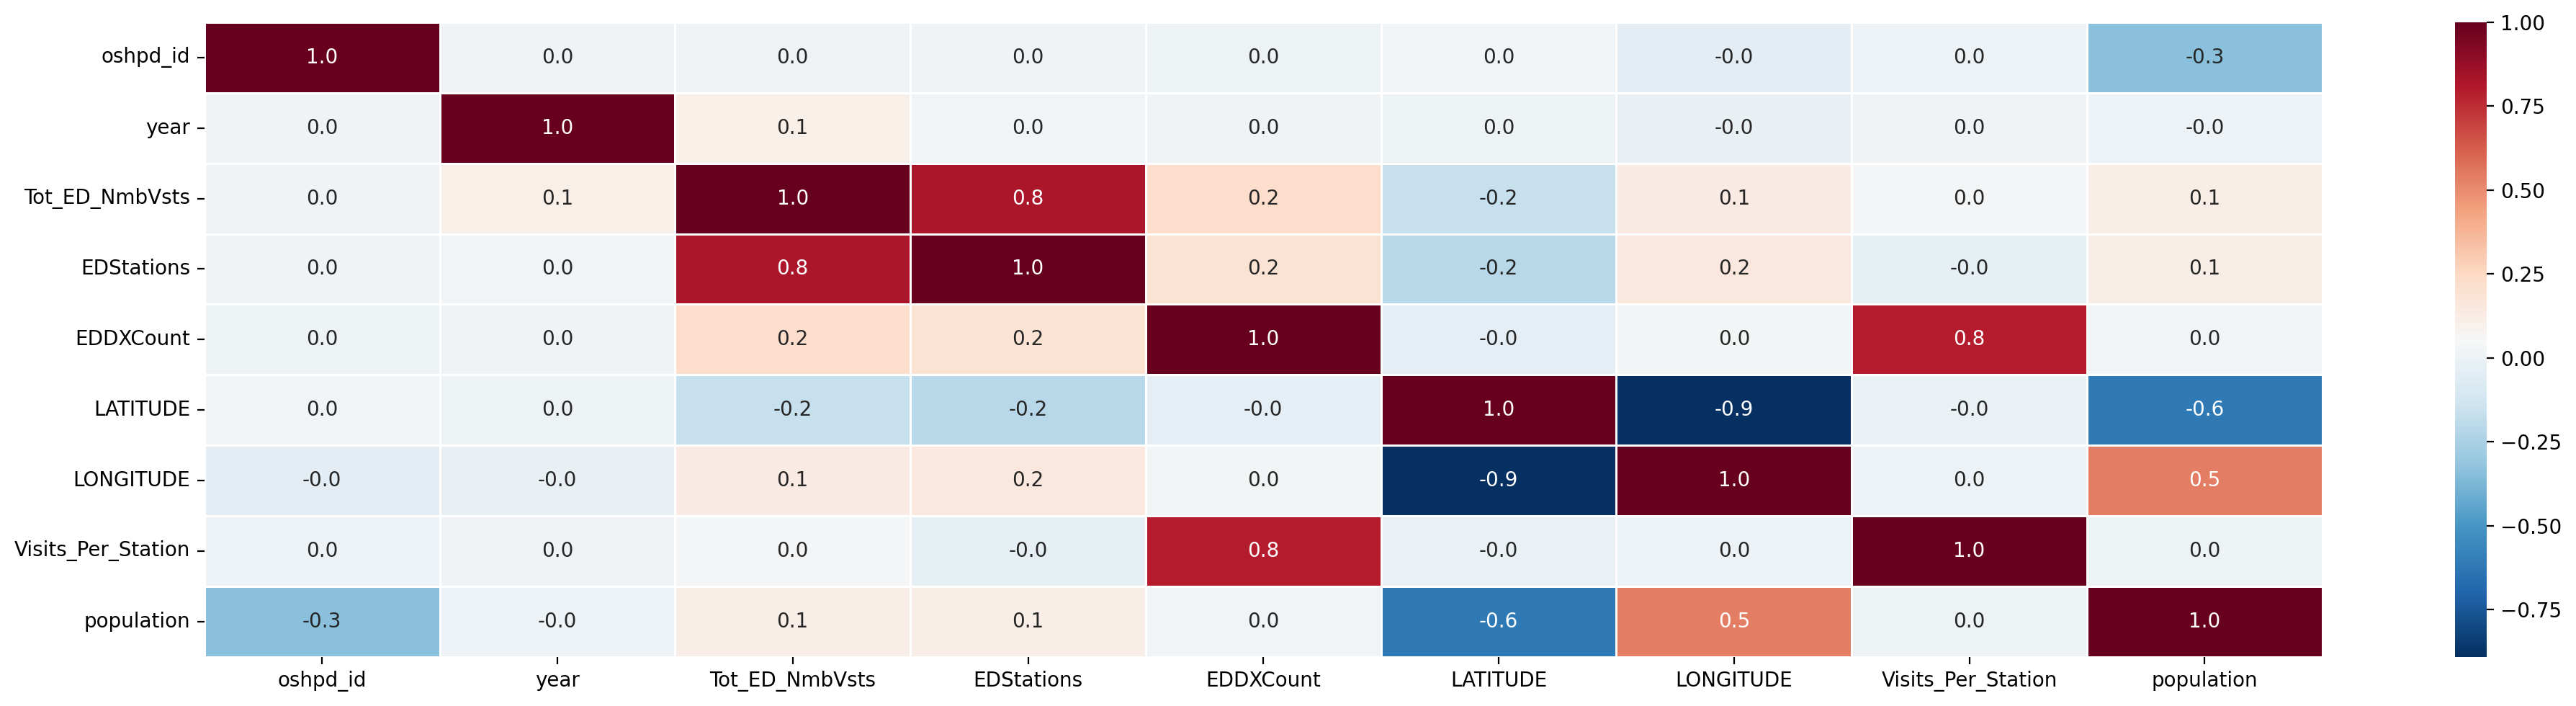

In [11]:
corr_df45 = df45.corr(numeric_only=True)

# 1) 그래프 초기화 
width_px = 4000                  # 그래프 가로 크기
height_px = 1000                 # 그래프 세로 크기
my_dpi = 200
rows = 1
cols = 1
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)


# 2) heatmap 그리기 
sb.heatmap(data=corr_df45, annot=True, fmt="0.1f", linewidth=0.5, cmap="RdBu_r")
# 3) 출력

plt.tight_layout()                          # 여백 제거
plt.show()                                  # 그래프 화면 출력
plt.close()  

# VIF

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

numeric_df = df45.select_dtypes(include=[np.number])

numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)

numeric_df_clean = numeric_df.dropna()

X_with_const = sm.add_constant(numeric_df_clean)

vif_data = pd.DataFrame()
vif_data["feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                   for i in range(len(X_with_const.columns))]
vif_data
# print(vif_data[vif_data['feature'] != 'const'.sort_values(by="VIF", ascending=False)])

,feature,VIF
0,const,7.018177e+06
1,oshpd_id,1.218079e+00
2,year,1.026102e+00
3,Tot_ED_NmbVsts,3.343845e+00
4,EDStations,3.452816e+00
5,EDDXCount,3.124992e+00
6,LATITUDE,5.915662e+00
7,LONGITUDE,4.878691e+00
8,Visits_Per_Station,3.003146e+00
9,population,1.964860e+00


# 상관계수 기준으로 삭제열 선택
1. LONGITUDE, LATITUDE : 삭제 (CountyName_명목형 -> 인코딩해 사용)
2. Visit_Per_Station : 삭제 (EDDXCount가 Target변수와 더 상관계수 높음)
3. system, oshpd_id와 FacilityName : 삭제 (병원 고유 식별자, 지역정보를 내포할 수 있으나 CountyName과 다중공선성 방지를 위해 삭제)
4. year : 삭제 (특정 기간에 한정된 단면 데이터, 모델 학습의 유효정보가 부재하여 삭제 조치)

In [13]:
df46 = df45.drop(columns=['oshpd_id','system','FacilityName2', 'year','Visits_Per_Station', 'LATITUDE', 'LONGITUDE'], axis=1)
df46

,CountyName,LICENSED_BED_SIZE,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,population
0,Alameda,100-149,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,No,No,1682353
1,Alameda,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,No,No,1682353
2,Alameda,150-199,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,No,No,1682353
3,Alameda,200-299,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,No,No,1682353
4,Alameda,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,No,No,1682353
...,...,...,...,...,...,...,...,...,...,...,...,...
12844,Ventura,100-149,Nonprofit,Urban,Non-Teaching,Substance Abuse,29223,18.0,1922,No,No,843843
12845,Ventura,200-299,Nonprofit,Urban,Non-Teaching,Substance Abuse,39699,31.0,2678,No,Yes,843843
12846,Yolo,100-149,Nonprofit,Urban,Non-Teaching,Substance Abuse,22210,17.0,1244,No,Yes,216403
12847,Yolo,1-49,Nonprofit,Urban,Non-Teaching,Substance Abuse,24455,11.0,1162,No,Yes,216403


In [14]:
df46.nunique()

CountyName                    53
LICENSED_BED_SIZE              7
HospitalOwnership              3
UrbanRuralDesi                 3
TEACHINGDesignation            2
Category                      17
Tot_ED_NmbVsts               754
EDStations                    80
EDDXCount                   4634
PrimaryCareShortageArea        2
MentalHealthShortageArea       2
population                    53
dtype: int64

In [15]:
df46.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12849 entries, 0 to 12848
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CountyName                12849 non-null  object 
 1   LICENSED_BED_SIZE         12849 non-null  object 
 2   HospitalOwnership         12849 non-null  object 
 3   UrbanRuralDesi            12849 non-null  object 
 4   TEACHINGDesignation       12849 non-null  object 
 5   Category                  12849 non-null  object 
 6   Tot_ED_NmbVsts            12849 non-null  int64  
 7   EDStations                12832 non-null  float64
 8   EDDXCount                 12849 non-null  int64  
 9   PrimaryCareShortageArea   12849 non-null  object 
 10  MentalHealthShortageArea  12849 non-null  object 
 11  population                12849 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 1.2+ MB


In [16]:
df46.isna().sum()

CountyName                   0
LICENSED_BED_SIZE            0
HospitalOwnership            0
UrbanRuralDesi               0
TEACHINGDesignation          0
Category                     0
Tot_ED_NmbVsts               0
EDStations                  17
EDDXCount                    0
PrimaryCareShortageArea      0
MentalHealthShortageArea     0
population                   0
dtype: int64

C:\Users\itwill\AppData\Local\Temp\ipykernel_25832\3133475061.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.kdeplot(data=df44, x="EDStations", fill=True, alpha=0.5, palette="pastel")


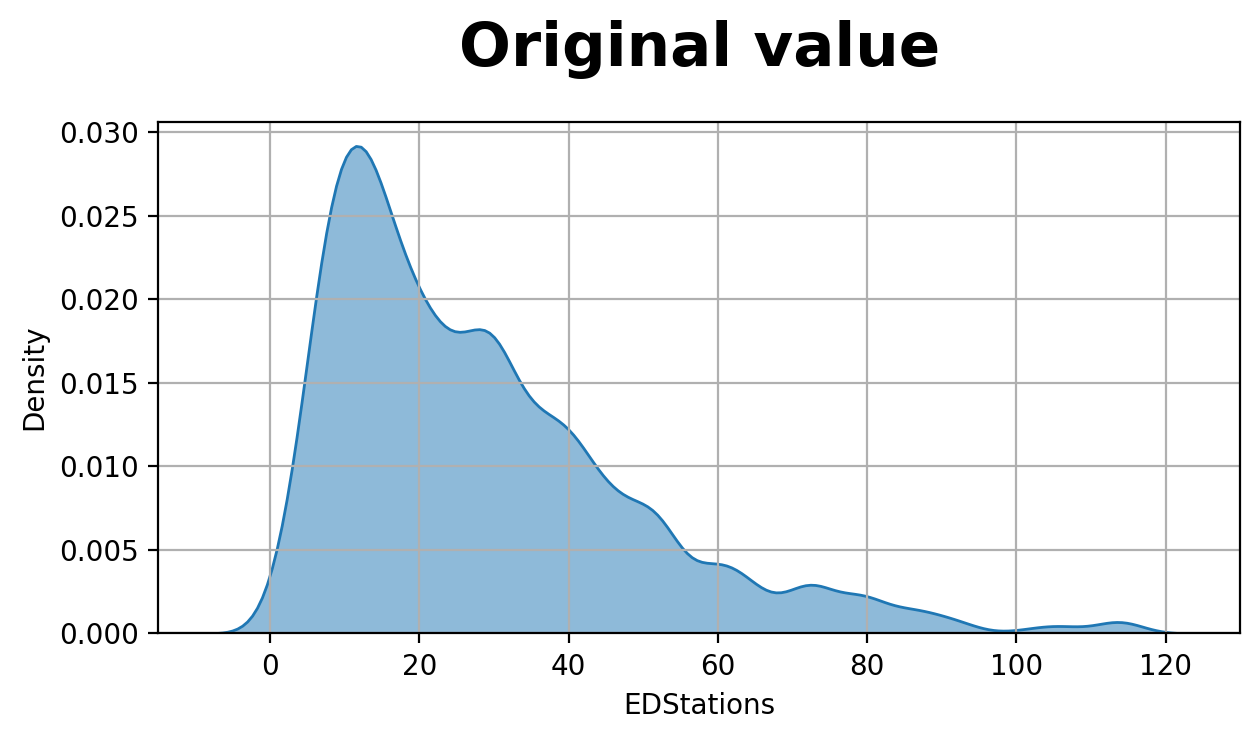

In [17]:
# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 1280                  # 그래프 가로 크기
height_px = 760                 # 그래프 세로 크기
rows = 1                         # 도화지의 행 수
cols = 1                        # 도화지의 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) 그래프 그리기 -> seaborn 사용
sb.kdeplot(data=df44, x="EDStations", fill=True, alpha=0.5, palette="pastel")

# 3) 그래프 꾸미기 -> 도화지(ax)에 직접 적용
ax.grid(True)                                  # 배경 격자 표시/ 숨김 (테마에 따라 다름)
ax.set_title("Original value", fontsize=22,
             fontweight=1000, pad=20)

# 4) 출력

plt.tight_layout()                          # 여백 제거
plt.savefig("myplot.png", dpi=my_dpi)       # 생략 가능
plt.show()                                  # 그래프 화면 출력
plt.close()  

# 결측치 중앙값 처리전 왜도

In [18]:
df44["EDStations"].skew()

1.316475231861919

### 응급실 의료 데이터 전처리 근거

논문 제목: Predictive models in emergency medicine and their missing data strategies: a systematic review

저자: J. M. Raymond, et al. (2023)

주요 내용: 응급의학 분야의 머신러닝 모델 구축 시 결측치 처리 전략을 검토하며, 단순 대입법 중 중앙값 대입이 데이터 분포의 왜곡을 최소화하는 실용적인 방법임을 설명합니다.

URL: https://pmc.ncbi.nlm.nih.gov/articles/PMC9950346/

In [19]:
df46.isna().sum()

CountyName                   0
LICENSED_BED_SIZE            0
HospitalOwnership            0
UrbanRuralDesi               0
TEACHINGDesignation          0
Category                     0
Tot_ED_NmbVsts               0
EDStations                  17
EDDXCount                    0
PrimaryCareShortageArea      0
MentalHealthShortageArea     0
population                   0
dtype: int64

In [20]:
df46.head()

,CountyName,LICENSED_BED_SIZE,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,population
0,Alameda,100-149,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,No,No,1682353
1,Alameda,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,No,No,1682353
2,Alameda,150-199,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,No,No,1682353
3,Alameda,200-299,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,No,No,1682353
4,Alameda,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,No,No,1682353


In [21]:
a = df46[df46['EDStations'].isna()]
a

,CountyName,LICENSED_BED_SIZE,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,population
60,Los Angeles,100-149,Investor Owned,Urban,Non-Teaching,Active COVID-19,20914,NaN,635,Yes,No,10014009
817,Los Angeles,100-149,Investor Owned,Urban,Non-Teaching,All ED Visits,20914,NaN,20914,Yes,No,10014009
1574,Los Angeles,100-149,Investor Owned,Urban,Non-Teaching,Asthma,20914,NaN,677,Yes,No,10014009
2331,Los Angeles,100-149,Investor Owned,Urban,Non-Teaching,COPD,20914,NaN,133,Yes,No,10014009
3085,Los Angeles,100-149,Investor Owned,Urban,Non-Teaching,COVID-19 History,20914,NaN,84,Yes,No,10014009
3840,Los Angeles,100-149,Investor Owned,Urban,Non-Teaching,Cancer,20914,NaN,81,Yes,No,10014009
4595,Los Angeles,100-149,Investor Owned,Urban,Non-Teaching,Cardiac,20914,NaN,17,Yes,No,10014009
5349,Los Angeles,100-149,Investor Owned,Urban,Non-Teaching,Diabetes,20914,NaN,2260,Yes,No,10014009
6104,Los Angeles,100-149,Investor Owned,Urban,Non-Teaching,Homeless,20914,NaN,234,Yes,No,10014009
6860,Los Angeles,100-149,Investor Owned,Urban,Non-Teaching,Hypertension,20914,NaN,3530,Yes,No,10014009


In [22]:
# EDStations의 중앙값을 먼저 구한 뒤, 그 값으로 빈칸을 채웁니다.
df46['EDStations'] = df46['EDStations'].fillna(df46['EDStations'].median())
df46.isnull().sum()

CountyName                  0
LICENSED_BED_SIZE           0
HospitalOwnership           0
UrbanRuralDesi              0
TEACHINGDesignation         0
Category                    0
Tot_ED_NmbVsts              0
EDStations                  0
EDDXCount                   0
PrimaryCareShortageArea     0
MentalHealthShortageArea    0
population                  0
dtype: int64

# 결측치 중앙값 처리 후 왜도

In [23]:
df46["EDStations"].skew()

1.3180837728346797

C:\Users\itwill\AppData\Local\Temp\ipykernel_25832\3103758645.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sb.kdeplot(data=df46, x="EDStations", fill=True, alpha=0.5, palette="pastel")


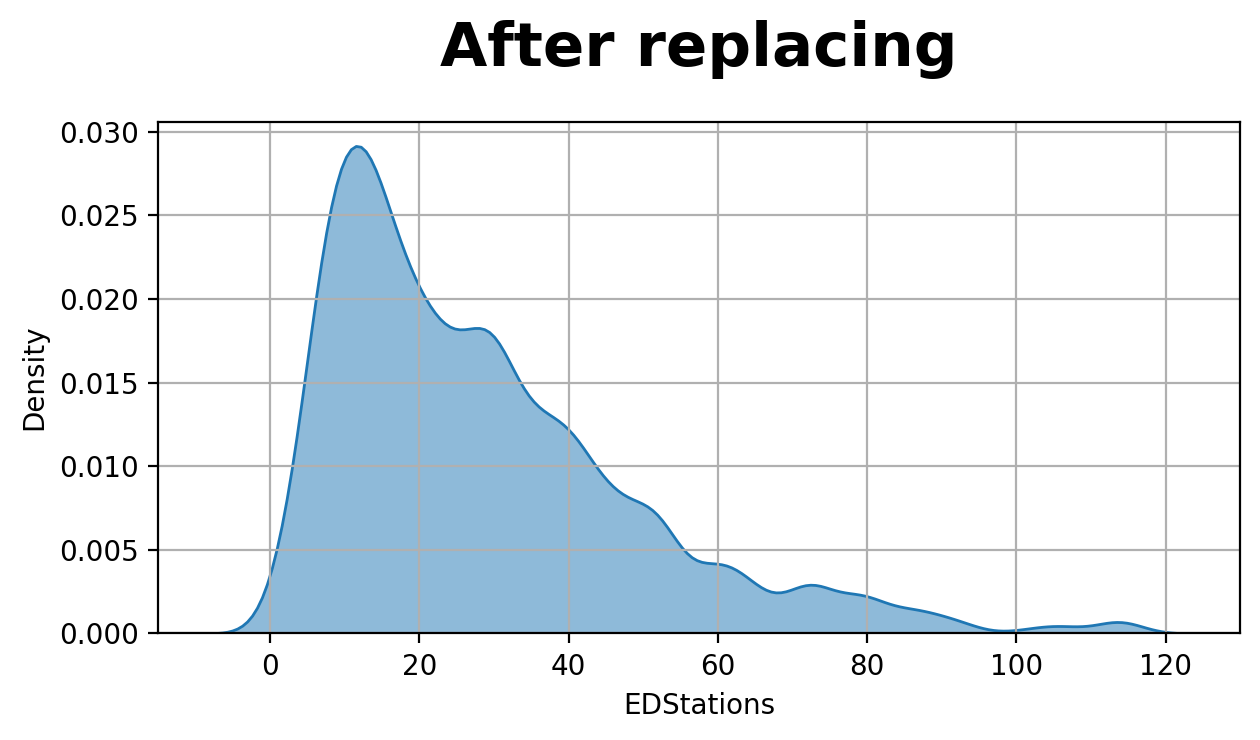

In [24]:
# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 1280                  # 그래프 가로 크기
height_px = 760                 # 그래프 세로 크기
rows = 1                         # 도화지의 행 수
cols = 1                        # 도화지의 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) 그래프 그리기 -> seaborn 사용
sb.kdeplot(data=df46, x="EDStations", fill=True, alpha=0.5, palette="pastel")

# 3) 그래프 꾸미기 -> 도화지(ax)에 직접 적용
ax.grid(True)                                  # 배경 격자 표시/ 숨김 (테마에 따라 다름)
ax.set_title("After replacing", fontsize=22,
             fontweight=1000, pad=20)

# 4) 출력

plt.tight_layout()                          # 여백 제거
plt.savefig("myplot.png", dpi=my_dpi)       # 생략 가능
plt.show()                                  # 그래프 화면 출력
plt.close()  

In [25]:
df46.head()

,CountyName,LICENSED_BED_SIZE,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,population
0,Alameda,100-149,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,No,No,1682353
1,Alameda,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,No,No,1682353
2,Alameda,150-199,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,No,No,1682353
3,Alameda,200-299,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,No,No,1682353
4,Alameda,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,No,No,1682353


In [26]:
df46.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12849 entries, 0 to 12848
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CountyName                12849 non-null  object 
 1   LICENSED_BED_SIZE         12849 non-null  object 
 2   HospitalOwnership         12849 non-null  object 
 3   UrbanRuralDesi            12849 non-null  object 
 4   TEACHINGDesignation       12849 non-null  object 
 5   Category                  12849 non-null  object 
 6   Tot_ED_NmbVsts            12849 non-null  int64  
 7   EDStations                12849 non-null  float64
 8   EDDXCount                 12849 non-null  int64  
 9   PrimaryCareShortageArea   12849 non-null  object 
 10  MentalHealthShortageArea  12849 non-null  object 
 11  population                12849 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 1.2+ MB


#### 'LICENSED_BED_SIZE'범주형 -> 라벨 인코딩

In [27]:
# 각 범주별 데이터 개수 확인
print(df46['LICENSED_BED_SIZE'].value_counts())

LICENSED_BED_SIZE
300-499    3125
200-299    2411
100-149    2307
150-199    1698
1-49       1508
50-99      1256
500+        544
Name: count, dtype: int64


In [28]:
# 예시: 확인한 종류를 바탕으로 순서 정하기
mapping = {
    '1-49': 1,
    '50-99': 2,
    '100-149': 3,
    '150-199': 4,
    '200-299': 5,
    '300-499': 6,
    '500+' : 7
    
}

df46['LICENSED_BED_SIZE_ENCODED'] = df46['LICENSED_BED_SIZE'].map(mapping)

In [29]:
df47 = df46.drop(columns=['LICENSED_BED_SIZE'])
df47

,CountyName,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,population,LICENSED_BED_SIZE_ENCODED
0,Alameda,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,No,No,1682353,3
1,Alameda,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,No,No,1682353,6
2,Alameda,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,No,No,1682353,4
3,Alameda,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,No,No,1682353,5
4,Alameda,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,No,No,1682353,6
...,...,...,...,...,...,...,...,...,...,...,...,...
12844,Ventura,Nonprofit,Urban,Non-Teaching,Substance Abuse,29223,18.0,1922,No,No,843843,3
12845,Ventura,Nonprofit,Urban,Non-Teaching,Substance Abuse,39699,31.0,2678,No,Yes,843843,5
12846,Yolo,Nonprofit,Urban,Non-Teaching,Substance Abuse,22210,17.0,1244,No,Yes,216403,3
12847,Yolo,Nonprofit,Urban,Non-Teaching,Substance Abuse,24455,11.0,1162,No,Yes,216403,1


In [30]:
df48 = df47.copy()
df48

,CountyName,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,population,LICENSED_BED_SIZE_ENCODED
0,Alameda,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,No,No,1682353,3
1,Alameda,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,No,No,1682353,6
2,Alameda,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,No,No,1682353,4
3,Alameda,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,No,No,1682353,5
4,Alameda,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,No,No,1682353,6
...,...,...,...,...,...,...,...,...,...,...,...,...
12844,Ventura,Nonprofit,Urban,Non-Teaching,Substance Abuse,29223,18.0,1922,No,No,843843,3
12845,Ventura,Nonprofit,Urban,Non-Teaching,Substance Abuse,39699,31.0,2678,No,Yes,843843,5
12846,Yolo,Nonprofit,Urban,Non-Teaching,Substance Abuse,22210,17.0,1244,No,Yes,216403,3
12847,Yolo,Nonprofit,Urban,Non-Teaching,Substance Abuse,24455,11.0,1162,No,Yes,216403,1


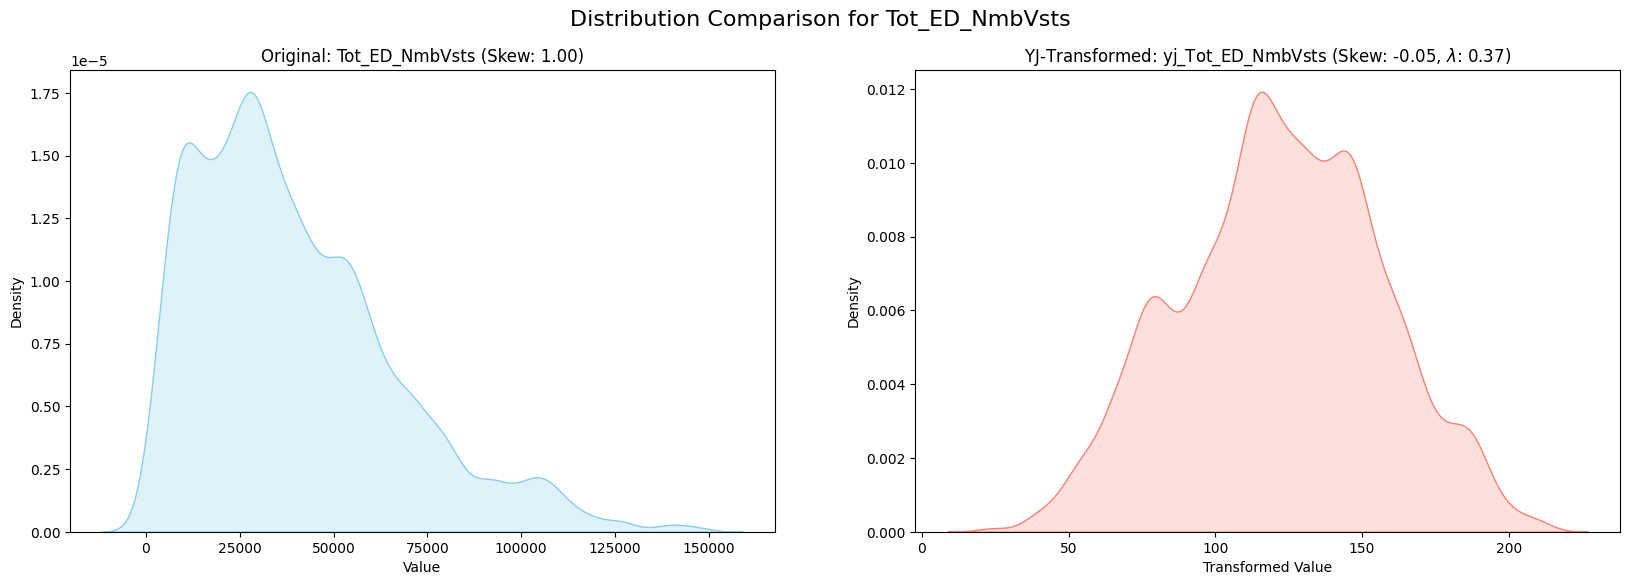

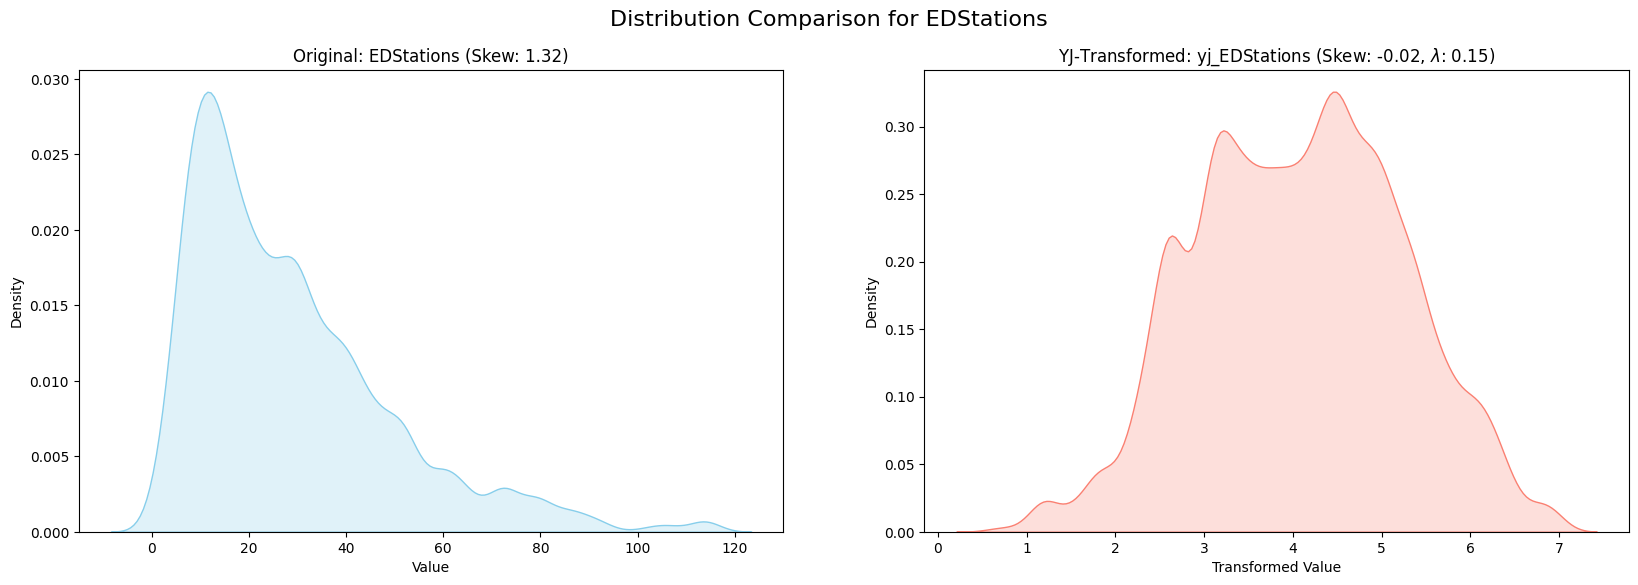

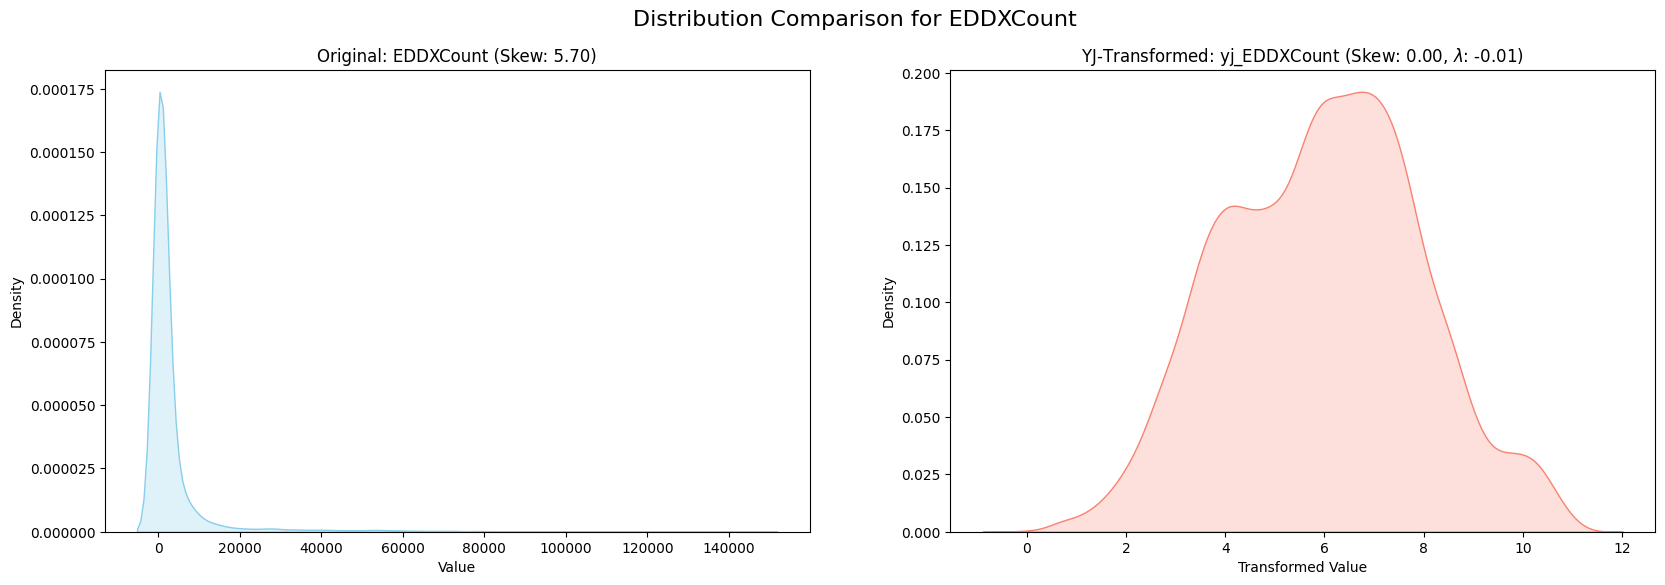

<Figure size 640x480 with 0 Axes>

In [ ]:
df49 = df48.copy()

from scipy import stats
import numpy as np
import pandas as pd

# 1) Yeo-Johnson 변환을 적용할 컬럼 리스트
target_cols = ['Tot_ED_NmbVsts', 'EDStations', 'EDDXCount']

results = []

# 2) 반복문을 사용하여 로그 변환 적용 (np.log1p 사용)
for col in target_cols:

    ori_skew = df49[col].skew()
    transformed_data, lmbda = stats.yeojohnson(df49[col])

    yj_col_name = f'yj_{col}'
    df49[yj_col_name] = transformed_data
    trans_skew = df49[yj_col_name].skew()

    results.append({
        'Column': col,
        'Original Skew': ori_skew,
        'YJ Transformed Skew': trans_skew,
        'Optimal Lambda': lmbda
    })

    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    fig.suptitle(f'Distribution Comparison for {col}', fontsize=16)

    sb.kdeplot(df49[col], fill=True, color='skyblue', ax=axes[0])
    axes[0].set_title(f'Original: {col} (Skew: {ori_skew:.2f})')
    axes[0].set_xlabel('Value')
    
    sb.kdeplot(df49[yj_col_name], fill=True, color='salmon', ax=axes[1])
    axes[1].set_title(f'YJ-Transformed: {yj_col_name} (Skew: {trans_skew:.2f}, $\lambda$: {lmbda:.2f})')
    axes[1].set_xlabel('Transformed Value')

    plt.show()

plt.tight_layout()
plt.show()


In [48]:
df49

,CountyName,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,population,LICENSED_BED_SIZE_ENCODED,yj_Tot_ED_NmbVsts,yj_EDStations,yj_EDDXCount
0,Alameda,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,No,No,1682353,3,86.749531,3.124918,6.037493
1,Alameda,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,No,No,1682353,6,116.593580,3.998156,6.793532
2,Alameda,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,No,No,1682353,4,123.990414,4.962100,7.195313
3,Alameda,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,No,No,1682353,5,157.170751,5.451428,7.329390
4,Alameda,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,No,No,1682353,6,115.967107,4.485507,6.902624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12844,Ventura,Nonprofit,Urban,Non-Teaching,Substance Abuse,29223,18.0,1922,No,No,843843,3,115.799180,3.697423,7.244312
12845,Ventura,Nonprofit,Urban,Non-Teaching,Substance Abuse,39699,31.0,2678,No,Yes,843843,5,129.897948,4.538632,7.547861
12846,Yolo,Nonprofit,Urban,Non-Teaching,Substance Abuse,22210,17.0,1244,No,Yes,216403,3,104.448408,3.613862,6.844541
12847,Yolo,Nonprofit,Urban,Non-Teaching,Substance Abuse,24455,11.0,1162,No,Yes,216403,1,108.301940,3.008249,6.781710


In [32]:
df4

,oshpd_id,FacilityName2,CountyName,system,year,LICENSED_BED_SIZE,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,LATITUDE,LONGITUDE,PrimaryCareShortageArea,MentalHealthShortageArea,Visits_Per_Station
0,106010735,Alameda Hospital,Alameda,Alameda Health System,2022,100-149,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,37.762660,-122.253991,No,No,43.333333
1,106010739,Alta Bates Summit Medical Center – Alta Bates ...,Alameda,Sutter Health,2022,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,37.856450,-122.257430,No,No,53.500000
2,106010776,UC San Francisco Benioff Children's Hospital O...,Alameda,NaN,2022,150-199,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,37.837220,-122.267470,No,No,45.550000
3,106010846,Highland Hospital,Alameda,Alameda Health System,2022,200-299,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,37.799250,-122.231380,No,No,39.792453
4,106010937,Alta Bates Summit Medical Center,Alameda,Sutter Health,2022,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,37.821060,-122.262570,No,No,44.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12844,106560525,Adventist Health Simi Valley,Ventura,Adventist Health Systems,2021,100-149,Nonprofit,Urban,Non-Teaching,Substance Abuse,29223,18.0,1922,34.289730,-118.743940,No,No,106.777778
12845,106560529,St. John's Regional Medical Center,Ventura,Dignity Health,2021,200-299,Nonprofit,Urban,Non-Teaching,Substance Abuse,39699,31.0,2678,34.216870,-119.158190,No,Yes,86.387097
12846,106571086,Woodland Memorial Hospital,Yolo,Dignity Health,2021,100-149,Nonprofit,Urban,Non-Teaching,Substance Abuse,22210,17.0,1244,38.662840,-121.793300,No,Yes,73.176471
12847,106574010,Sutter Davis Hospital,Yolo,Sutter Health,2021,1-49,Nonprofit,Urban,Non-Teaching,Substance Abuse,24455,11.0,1162,38.562890,-121.771640,No,Yes,105.636364


In [33]:
df49

,CountyName,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,population,LICENSED_BED_SIZE_ENCODED,yj_Tot_ED_NmbVsts,yj_EDStations,yj_EDDXCount
0,Alameda,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,No,No,1682353,3,86.749531,3.124918,6.037493
1,Alameda,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,No,No,1682353,6,116.593580,3.998156,6.793532
2,Alameda,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,No,No,1682353,4,123.990414,4.962100,7.195313
3,Alameda,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,No,No,1682353,5,157.170751,5.451428,7.329390
4,Alameda,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,No,No,1682353,6,115.967107,4.485507,6.902624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12844,Ventura,Nonprofit,Urban,Non-Teaching,Substance Abuse,29223,18.0,1922,No,No,843843,3,115.799180,3.697423,7.244312
12845,Ventura,Nonprofit,Urban,Non-Teaching,Substance Abuse,39699,31.0,2678,No,Yes,843843,5,129.897948,4.538632,7.547861
12846,Yolo,Nonprofit,Urban,Non-Teaching,Substance Abuse,22210,17.0,1244,No,Yes,216403,3,104.448408,3.613862,6.844541
12847,Yolo,Nonprofit,Urban,Non-Teaching,Substance Abuse,24455,11.0,1162,No,Yes,216403,1,108.301940,3.008249,6.781710


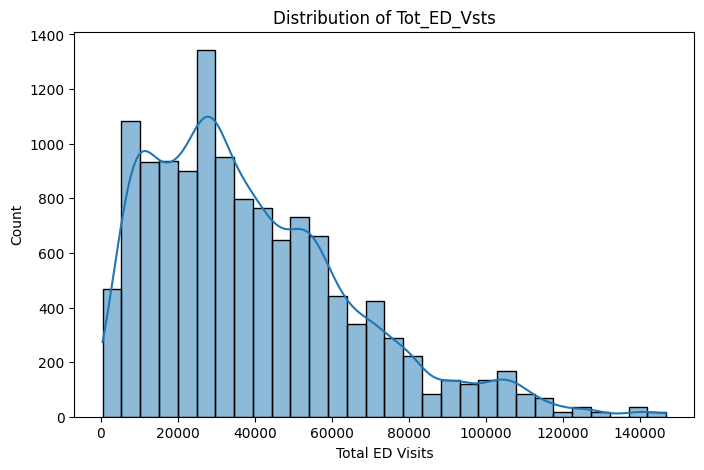

In [34]:
import seaborn as sb
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sb.histplot(df49['Tot_ED_NmbVsts'], bins=30, kde=True)

plt.title("Distribution of Tot_ED_Vsts")
plt.xlabel("Total ED Visits")
plt.ylabel("Count")

plt.show()

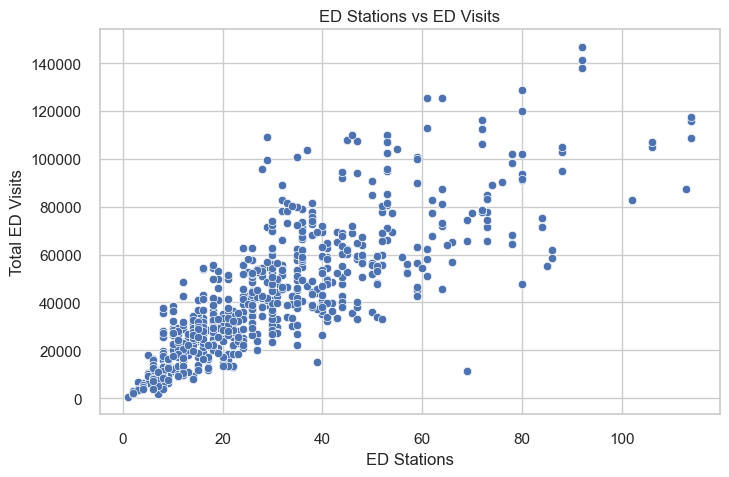

In [130]:
plt.figure(figsize=(8,5))

sb.scatterplot(
    x=df49['EDStations'],
    y=df49['Tot_ED_NmbVsts']
)

plt.title("ED Stations vs ED Visits")
plt.xlabel("ED Stations")
plt.ylabel("Total ED Visits")

plt.show()

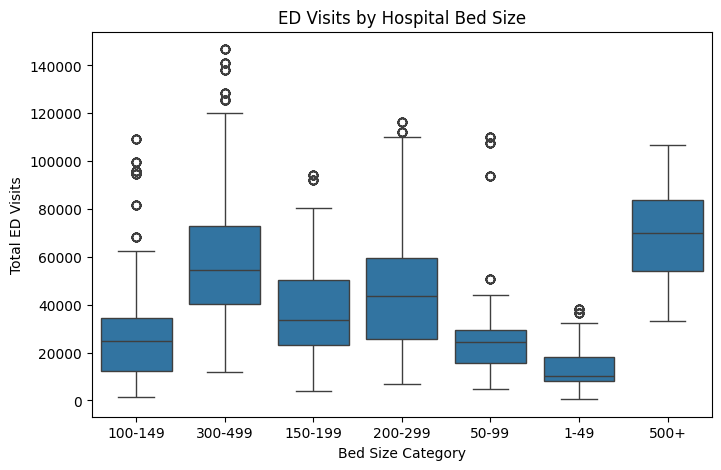

In [36]:
plt.figure(figsize=(8,5))

sb.boxplot(
    x=df44['LICENSED_BED_SIZE'],
    y=df44['Tot_ED_NmbVsts']
)

plt.title("ED Visits by Hospital Bed Size")
plt.xlabel("Bed Size Category")
plt.ylabel("Total ED Visits")

plt.show()

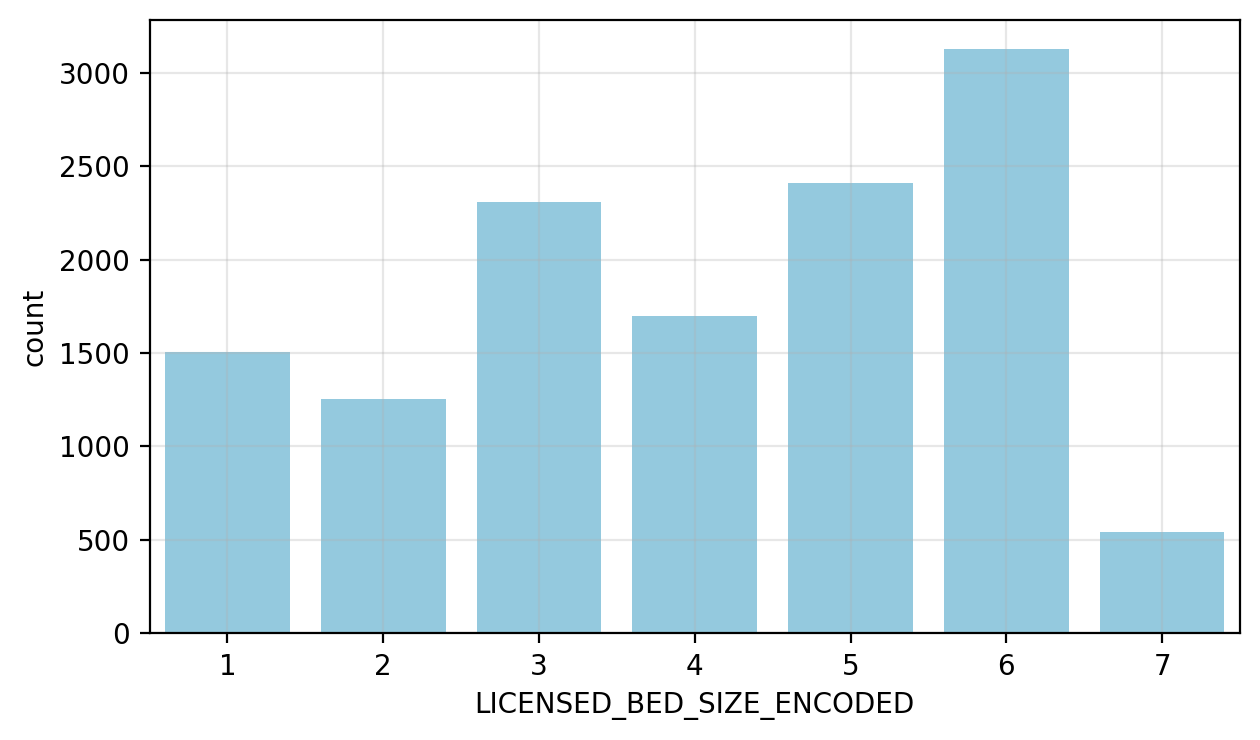

In [37]:
import seaborn as sb
import matplotlib.pyplot as plt

# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 1280                  # 그래프 가로 크기
height_px = 760                 # 그래프 세로 크기
rows = 1                         # 도화지의 행 수
cols = 1                        # 도화지의 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) BoxPlot 그리기
sb.countplot(data=df48, x='LICENSED_BED_SIZE_ENCODED', color='skyblue')

# 3) 그래프 꾸미기 -> 도화지(ax)에 직접 적용
ax.grid(True, alpha=0.3)                                  # 배경 격자 표시/ 숨김 (테마에 따라 다름)

# 4) 출력
plt.tight_layout()                          # 여백 제거
plt.show()                                  # 그래프 화면 출력
plt.close()  

In [38]:
df48.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12849 entries, 0 to 12848
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CountyName                 12849 non-null  object 
 1   HospitalOwnership          12849 non-null  object 
 2   UrbanRuralDesi             12849 non-null  object 
 3   TEACHINGDesignation        12849 non-null  object 
 4   Category                   12849 non-null  object 
 5   Tot_ED_NmbVsts             12849 non-null  int64  
 6   EDStations                 12849 non-null  float64
 7   EDDXCount                  12849 non-null  int64  
 8   PrimaryCareShortageArea    12849 non-null  object 
 9   MentalHealthShortageArea   12849 non-null  object 
 10  population                 12849 non-null  int64  
 11  LICENSED_BED_SIZE_ENCODED  12849 non-null  int64  
dtypes: float64(1), int64(4), object(7)
memory usage: 1.2+ MB


C:\Users\itwill\AppData\Local\Temp\ipykernel_25832\1879614458.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=df48, x=col, ax=ax, palette='Set3')


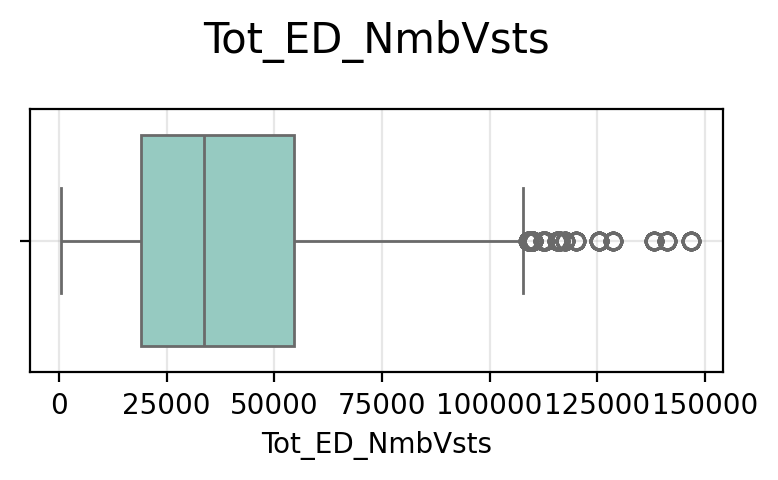

C:\Users\itwill\AppData\Local\Temp\ipykernel_25832\1879614458.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=df48, x=col, ax=ax, palette='Set3')


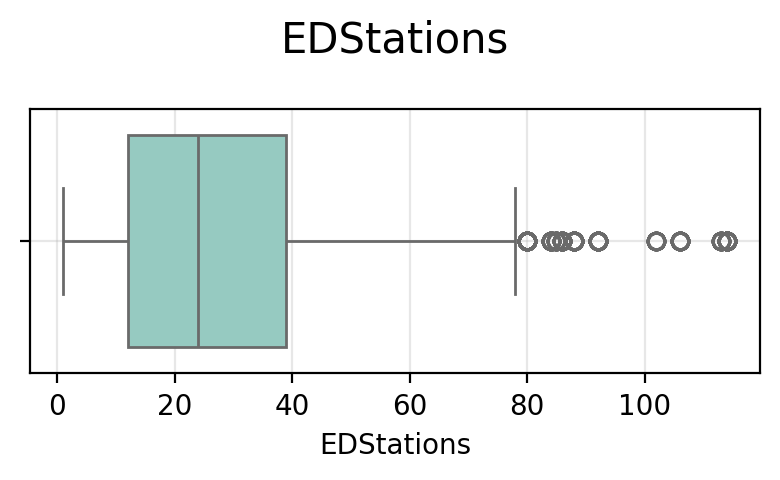

C:\Users\itwill\AppData\Local\Temp\ipykernel_25832\1879614458.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=df48, x=col, ax=ax, palette='Set3')


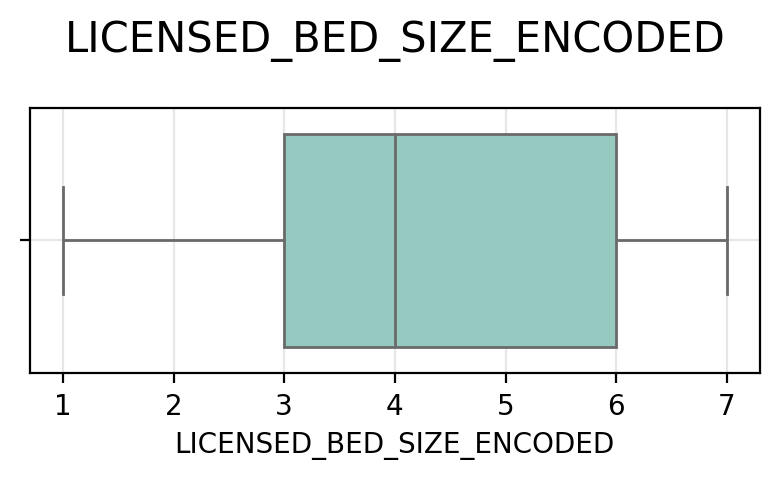

C:\Users\itwill\AppData\Local\Temp\ipykernel_25832\1879614458.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=df48, x=col, ax=ax, palette='Set3')


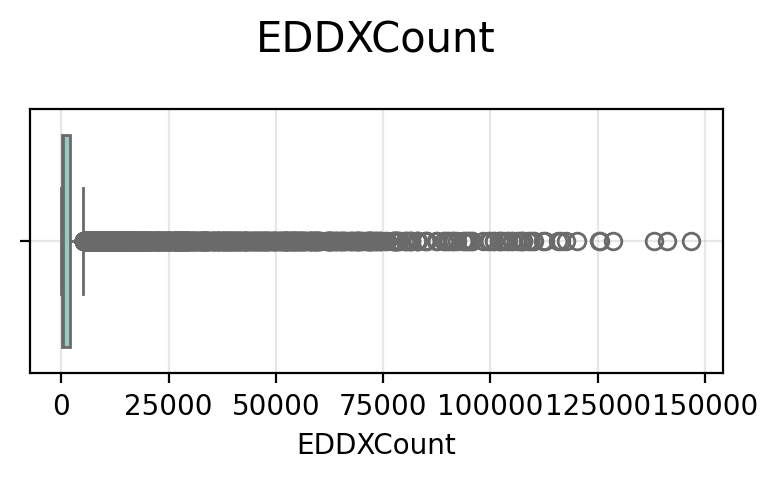

In [39]:
# 1) 분석할 수치형 컬럼 리스트업
target_cols = ['Tot_ED_NmbVsts', 'EDStations', 'LICENSED_BED_SIZE_ENCODED', 'EDDXCount']

# 2) 반복문을 이용한 그래프 생성
for col in target_cols:
    width_px = 800  
    height_px = 500
    figsize = (width_px / my_dpi, height_px / my_dpi)
    
    fig, ax = plt.subplots(figsize=figsize, dpi=my_dpi)
    
    # BoxPlot 그리기
    sb.boxplot(data=df48, x=col, ax=ax, palette='Set3')
    
    # 그래프 꾸미기
    ax.set_title(f'{col}', fontsize=15, pad=20)
    ax.grid(True, alpha=0.3)
    
    # 출력
    plt.tight_layout()
    plt.show()
    plt.close()

논문 근거 -> url, 저자이름, 제목 첨부 필

In [40]:


from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np
from itertools import combinations

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, learning_curve

from sklearn.metrics import(
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

from scipy.stats import shapiro, jarque_bera, t, f

from statsmodels.stats.api import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.graphics.gofplots import qqplot as sm_qqplot
import statsmodels.api as sm

In [41]:
df49

,CountyName,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,population,LICENSED_BED_SIZE_ENCODED,yj_Tot_ED_NmbVsts,yj_EDStations,yj_EDDXCount
0,Alameda,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,No,No,1682353,3,86.749531,3.124918,6.037493
1,Alameda,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,No,No,1682353,6,116.593580,3.998156,6.793532
2,Alameda,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,No,No,1682353,4,123.990414,4.962100,7.195313
3,Alameda,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,No,No,1682353,5,157.170751,5.451428,7.329390
4,Alameda,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,No,No,1682353,6,115.967107,4.485507,6.902624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12844,Ventura,Nonprofit,Urban,Non-Teaching,Substance Abuse,29223,18.0,1922,No,No,843843,3,115.799180,3.697423,7.244312
12845,Ventura,Nonprofit,Urban,Non-Teaching,Substance Abuse,39699,31.0,2678,No,Yes,843843,5,129.897948,4.538632,7.547861
12846,Yolo,Nonprofit,Urban,Non-Teaching,Substance Abuse,22210,17.0,1244,No,Yes,216403,3,104.448408,3.613862,6.844541
12847,Yolo,Nonprofit,Urban,Non-Teaching,Substance Abuse,24455,11.0,1162,No,Yes,216403,1,108.301940,3.008249,6.781710


In [42]:
df49.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12849 entries, 0 to 12848
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CountyName                 12849 non-null  object 
 1   HospitalOwnership          12849 non-null  object 
 2   UrbanRuralDesi             12849 non-null  object 
 3   TEACHINGDesignation        12849 non-null  object 
 4   Category                   12849 non-null  object 
 5   Tot_ED_NmbVsts             12849 non-null  int64  
 6   EDStations                 12849 non-null  float64
 7   EDDXCount                  12849 non-null  int64  
 8   PrimaryCareShortageArea    12849 non-null  object 
 9   MentalHealthShortageArea   12849 non-null  object 
 10  population                 12849 non-null  int64  
 11  LICENSED_BED_SIZE_ENCODED  12849 non-null  int64  
 12  yj_Tot_ED_NmbVsts          12849 non-null  float64
 13  yj_EDStations              12849 non-null  flo

In [43]:
df49['Category'].value_counts()

Category
Active COVID-19     757
Diabetes            757
Pneumonia           757
Obesity             757
Mental Health       757
Hypertension        757
All ED Visits       757
Substance Abuse     757
Asthma              757
Cancer              756
Sepsis              756
COPD                755
Respiratory         755
COVID-19 History    754
Homeless            754
Cardiac             753
Stroke              753
Name: count, dtype: int64

# 카운티 인구수 내림차순

In [44]:
county_pop = df49.groupby('CountyName')['population'].max().sort_values(ascending=False)
print(county_pop)

CountyName
Los Angeles        10014009
San Diego           3298634
Orange              3186989
Riverside           2418185
San Bernardino      2181654
Santa Clara         1936259
Alameda             1682353
Sacramento          1585055
Contra Costa        1165927
Fresno              1008654
Kern                 909235
San Francisco        873965
Ventura              843843
San Joaquin          779233
San Mateo            764442
Stanislaus           552878
Sonoma               488863
Tulare               473117
Solano               453491
Santa Barbara        448229
Monterey             439035
Placer               404739
San Luis Obispo      282424
Merced               281202
Santa Cruz           270861
Marin                262321
Yolo                 216403
Butte                211632
El Dorado            191185
Shasta               182155
Imperial             179702
Madera               156255
Kings                152486
Napa                 138019
Humboldt             136463
Nevada   

In [45]:
df_all_visits = df49[df49['Category'] == 'All ED Visits']

county_all_visits = df_all_visits.groupby('CountyName')['Tot_ED_NmbVsts'].sum().sort_values(ascending=False)

print(county_all_visits)

CountyName
Los Angeles        7196266
San Diego          1994804
Orange             1873830
San Bernardino     1759004
Riverside          1733857
Alameda            1429243
Sacramento         1305826
Santa Clara        1121187
San Joaquin         926666
Fresno              861327
Contra Costa        846612
Kern                669048
Stanislaus          661001
Placer              582583
Solano              570467
Ventura             544948
San Francisco       529307
San Mateo           475733
Monterey            420635
Sonoma              369538
Tulare              344475
Santa Barbara       344003
San Luis Obispo     280234
Kings               266956
Madera              261480
Merced              249085
Marin               216019
Butte               214224
Shasta              214168
Yuba                179097
Mendocino           151871
Yolo                133812
Santa Cruz          123644
Lake                112475
Imperial            110281
El Dorado           103310
Humboldt         

# Pycaret

In [46]:

from pandas import concat
from pycaret.regression import *
from pycaret.regression import RegressionExperiment

In [49]:
# 코드 구문 설명입니다.
s = RegressionExperiment()
s.setup(
    #-----------------------
    # 기본 설정 (필수 지정)
    #-----------------------
    # 데이터셋 지정
    data = df49,
    # 예측 목표 변수 지정
    target="yj_Tot_ED_NmbVsts",
    # 랜덤 시드 고정
    session_id=52,
    # 훈련 데이터 비윺ㄹ (기본값=0.7)
    train_size=0.75,
    # 교차검증 폴드 수 지정
    fold = 5,
    # 처리과정 출력 안함 (기본값 True, False 권장. 출력 과정이 다소 길어질 수 있음)
    verbose=False,
    # GPU 사용 여부 지정 (기본값 False) - True로 설정하면 컴퓨터 환경에 따라 지원 안될 경우 에러 발생
    use_gpu = False,
    #-----------------------
    # 전처리 설정 (1)
    #-----------------------
    # 범주형 변수 지정(기본값 None)
    ignore_features=['Tot_ED_NmbVsts', 'EDStations', 'EDDXCount', 'oshpd_id', 'FacilityName2'],
    # 데이터 정규화/표준화 활성화(기본값 False)
    normalize=True,
    # 데이터 정규화/표준화 방법 선택(zscore가 StandardScaler와 동일)
    # 'minmax', 'maxabs', 'robust', 'zscore'
    normalize_method='zscore',
    #-----------------------
    # 전처리 설정 (2) - 아래 기능은 사용하지 말고, 데이터 별도의 전처리 단계를 거치는 것을 권장
    #-----------------------
    # 이상치 제거 (기본값 False, IQR 범위 밖의 값을 삭제함)
    remove_outliers=False,
    # 이상치 제거 임계값 (기본ㄱ밧 0.05, 상하위 몇 %를 이상치로 간주할지 지정)
    outliers_threshold=0.05,
    # 종속변수 변환 (기본값 False)
    transform_target=False,
    # 변수 선택 (기본값 False)
    feature_selection=False
)

In [50]:
s.pull()

,Description,Value
0,Session id,52
1,Target,yj_Tot_ED_NmbVsts
2,Target type,Regression
3,Original data shape,"(12849, 15)"
4,Transformed data shape,"(12849, 32)"
5,Transformed train set shape,"(9636, 32)"
6,Transformed test set shape,"(3213, 32)"
7,Ignore features,5
8,Numeric features,4
9,Categorical features,7


In [52]:
s.models()

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.Elast...,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPu...,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


In [53]:
model = s.create_model("xgboost")
model

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.0987,17.0752,4.1322,0.9851,0.0338,0.0261
1,3.1205,17.2093,4.1484,0.9852,0.0332,0.0259
2,3.1426,16.9437,4.1163,0.9858,0.0337,0.0265
3,3.1557,16.9706,4.1195,0.9862,0.0336,0.0266
4,3.0739,16.5360,4.0664,0.9862,0.0332,0.0260
Mean,3.1183,16.9470,4.1166,0.9857,0.0335,0.0262
Std,0.0295,0.2257,0.0275,0.0004,0.0002,0.0003


XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cpu', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=-1,
             num_parallel_tree=None, random_state=52, ...)

In [54]:
best5models = s.compare_models(sort='RMSE', n_select=5, fold=5)
best5models

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
xgboost,Extreme Gradient Boosting,3.1183,16.9470,4.1166,0.9857,0.0335,0.0262,0.0700
catboost,CatBoost Regressor,3.3748,19.2461,4.3863,0.9838,0.0362,0.0287,0.7260
rf,Random Forest Regressor,3.0356,19.4328,4.4075,0.9836,0.0358,0.0256,0.3380
lightgbm,Light Gradient Boosting Machine,3.6431,22.5624,4.7483,0.9810,0.0416,0.0317,0.1140
et,Extra Trees Regressor,3.5853,27.7692,5.2694,0.9766,0.0426,0.0302,0.3260
dt,Decision Tree Regressor,3.4453,29.4453,5.4234,0.9752,0.0439,0.0290,0.0420
gbr,Gradient Boosting Regressor,7.7573,102.5820,10.1206,0.9136,0.0871,0.0678,0.2060
lar,Least Angle Regression,10.9017,197.4806,14.0505,0.8336,0.1277,0.0977,0.0340
br,Bayesian Ridge,10.9039,197.4801,14.0505,0.8336,0.1276,0.0977,0.0360
ridge,Ridge Regression,10.9020,197.4802,14.0505,0.8336,0.1277,0.0977,0.0500


[XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cpu', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, random_state=52, ...),
 RandomForestRegressor(n_jobs=-1, random_state=52),
 LGBMRegressor(n_jobs=-1, random_state=52),
 ExtraTreesRegressor(n_jobs=-1, random_state=52)]

In [62]:
best5models = s.compare_models(include=["xgboost","catboost","rf","lightgbm","et","dt","gbr","lar","br","ridge"], sort='RMSE', n_select=5, fold=5)
best5models

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
xgboost,Extreme Gradient Boosting,3.1183,16.9470,4.1166,0.9857,0.0335,0.0262,0.0800
catboost,CatBoost Regressor,3.3748,19.2461,4.3863,0.9838,0.0362,0.0287,0.6460
rf,Random Forest Regressor,3.0356,19.4328,4.4075,0.9836,0.0358,0.0256,0.3580
lightgbm,Light Gradient Boosting Machine,3.6431,22.5624,4.7483,0.9810,0.0416,0.0317,0.1180
et,Extra Trees Regressor,3.5853,27.7692,5.2694,0.9766,0.0426,0.0302,0.3320
dt,Decision Tree Regressor,3.4453,29.4453,5.4234,0.9752,0.0439,0.0290,0.0500
gbr,Gradient Boosting Regressor,7.7573,102.5820,10.1206,0.9136,0.0871,0.0678,0.1860
lar,Least Angle Regression,10.9017,197.4806,14.0505,0.8336,0.1277,0.0977,0.0420
br,Bayesian Ridge,10.9039,197.4801,14.0505,0.8336,0.1276,0.0977,0.0380
ridge,Ridge Regression,10.9020,197.4802,14.0505,0.8336,0.1277,0.0977,0.0400


[XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cpu', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, random_state=52, ...),
 RandomForestRegressor(n_jobs=-1, random_state=52),
 LGBMRegressor(n_jobs=-1, random_state=52),
 ExtraTreesRegressor(n_jobs=-1, random_state=52)]

## Pycaret 모델 선택 기준 근거
- "Machine learning for predicting waiting time in emergency departments"
    - 저자: Z. Mekni, et al. (2023)내용: 인공지능 기반의 응급실 혼잡도 예측 시스템을 구축하며 $R^2$와 RMSE를 주 지표로 활용했습니다.
    - 핵심 근거: $R^2$는 모델이 전체 변동성의 몇 %를 설명하는지 보여주며, RMSE는 실제 대기 시간(분 단위)의 물리적 오차를 제어하는 도구로 쓰입니다.
    - URL: https://www.nature.com/articles/s41598-024-52311-1

### Pycaret Bestmodel -> XGBoost

In [63]:
blended = s.blend_models(estimator_list=best5models, fold=5)
blended

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.1315,17.4212,4.1739,0.9848,0.0342,0.0265
1,3.1406,17.5422,4.1883,0.9850,0.0340,0.0263
2,3.2113,17.6941,4.2064,0.9852,0.0345,0.0272
3,3.2400,18.0736,4.2513,0.9853,0.0348,0.0275
4,3.1327,17.5111,4.1846,0.9854,0.0342,0.0266
Mean,3.1712,17.6484,4.2009,0.9851,0.0343,0.0268
Std,0.0455,0.2301,0.0273,0.0002,0.0003,0.0005


VotingRegressor(estimators=[('Extreme Gradient Boosting',
                             XGBRegressor(base_score=None, booster='gbtree',
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device='cpu',
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_const...
                                          num_parallel_tree=None,
                                          random_state=52, ...)),
                            ('CatBoost Regressor',
                             <catboost.core.CatBoostRegressor object at 0x000002685CC183D0>),
                            ('Random Forest Regressor',
                             RandomForestRegressor(n_jobs=-1, random_state=52)),
                            ('Light Gradient Boosting Machine',
                             LGBMRegressor(n_jobs=-1, random_state=52)),
                            ('Extra Trees Regressor',
                             ExtraTreesRegressor(n_jobs=-1, random_state=52))],
                n_jobs=-1)

In [65]:
s.predict_model(best5models[0])

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,3.0669,15.9328,3.9916,0.9856,0.0324,0.0255


,CountyName,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,PrimaryCareShortageArea,MentalHealthShortageArea,population,LICENSED_BED_SIZE_ENCODED,yj_EDStations,yj_EDDXCount,yj_Tot_ED_NmbVsts,prediction_label
4093,Los Angeles,Investor Owned,Urban,Non-Teaching,Cancer,No,No,10014009,5,3.124918,4.936761,105.569427,102.537109
11031,San Francisco,Nonprofit,Urban,Non-Teaching,Sepsis,No,Yes,873965,5,4.737931,4.225372,117.528587,111.111519
6628,Los Angeles,Nonprofit,Urban,Non-Teaching,Homeless,No,No,10014009,6,4.257248,6.472135,119.131050,126.243187
6960,Sacramento,Government,Urban,Teaching,Hypertension,No,No,1585055,7,5.848973,8.945493,156.374802,151.365250
12444,Los Angeles,Nonprofit,Urban,Non-Teaching,Substance Abuse,No,No,10014009,6,4.485507,7.358870,146.289017,140.300095
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11948,Madera,Nonprofit,Rural,Non-Teaching,Stroke,Yes,Yes,156255,6,4.875383,1.594736,163.912048,168.429871
5921,Orange,Nonprofit,Urban,Non-Teaching,Diabetes,No,No,3186989,6,6.392167,8.625243,179.922638,184.347275
12771,San Bernardino,Nonprofit,Urban,Non-Teaching,Substance Abuse,No,Yes,2181654,5,5.085657,7.372222,143.793488,151.768478
11121,Fresno,Nonprofit,Urban,Non-Teaching,Sepsis,No,Yes,1008654,4,3.927419,5.036706,131.962143,140.883316


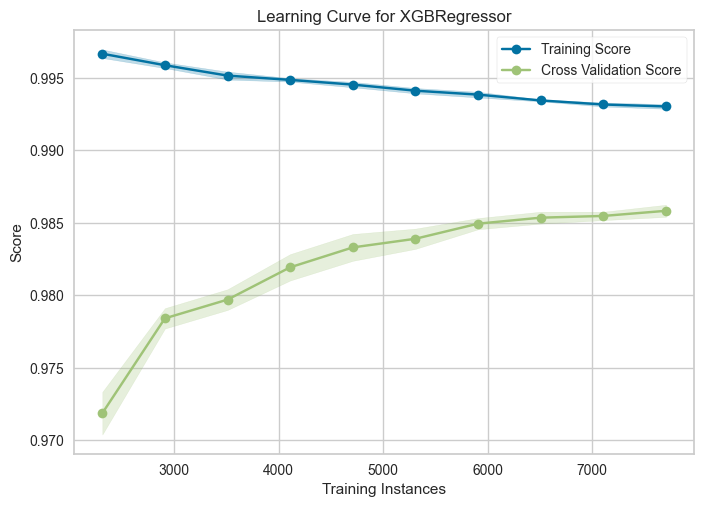

In [66]:
s.plot_model(best5models[0], plot='learning')

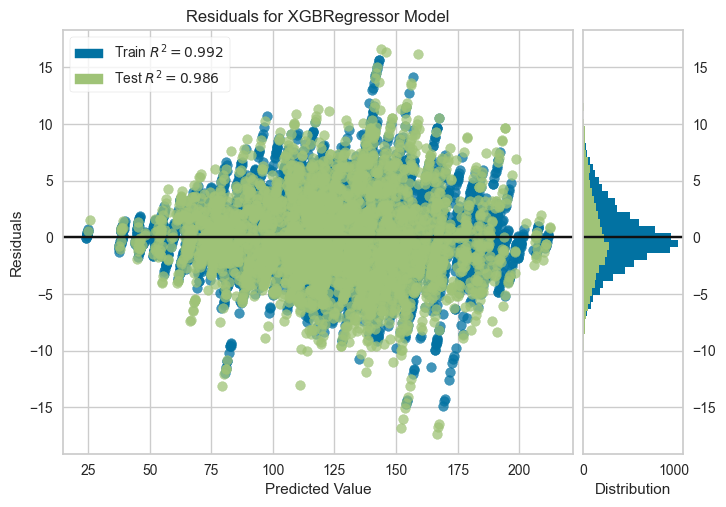

In [67]:
s.plot_model(best5models[0], plot='residuals')

In [68]:
s.predict_model(blended)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Voting Regressor,3.2213,17.8322,4.2228,0.9839,0.0342,0.0269


,CountyName,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,PrimaryCareShortageArea,MentalHealthShortageArea,population,LICENSED_BED_SIZE_ENCODED,yj_EDStations,yj_EDDXCount,yj_Tot_ED_NmbVsts,prediction_label
4093,Los Angeles,Investor Owned,Urban,Non-Teaching,Cancer,No,No,10014009,5,3.124918,4.936761,105.569427,102.166806
11031,San Francisco,Nonprofit,Urban,Non-Teaching,Sepsis,No,Yes,873965,5,4.737931,4.225372,117.528587,112.789911
6628,Los Angeles,Nonprofit,Urban,Non-Teaching,Homeless,No,No,10014009,6,4.257248,6.472135,119.131050,126.102582
6960,Sacramento,Government,Urban,Teaching,Hypertension,No,No,1585055,7,5.848973,8.945493,156.374802,153.765036
12444,Los Angeles,Nonprofit,Urban,Non-Teaching,Substance Abuse,No,No,10014009,6,4.485507,7.358870,146.289017,139.925646
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11948,Madera,Nonprofit,Rural,Non-Teaching,Stroke,Yes,Yes,156255,6,4.875383,1.594736,163.912048,168.051087
5921,Orange,Nonprofit,Urban,Non-Teaching,Diabetes,No,No,3186989,6,6.392167,8.625243,179.922638,184.815350
12771,San Bernardino,Nonprofit,Urban,Non-Teaching,Substance Abuse,No,Yes,2181654,5,5.085657,7.372222,143.793488,153.738112
11121,Fresno,Nonprofit,Urban,Non-Teaching,Sepsis,No,Yes,1008654,4,3.927419,5.036706,131.962143,139.251701


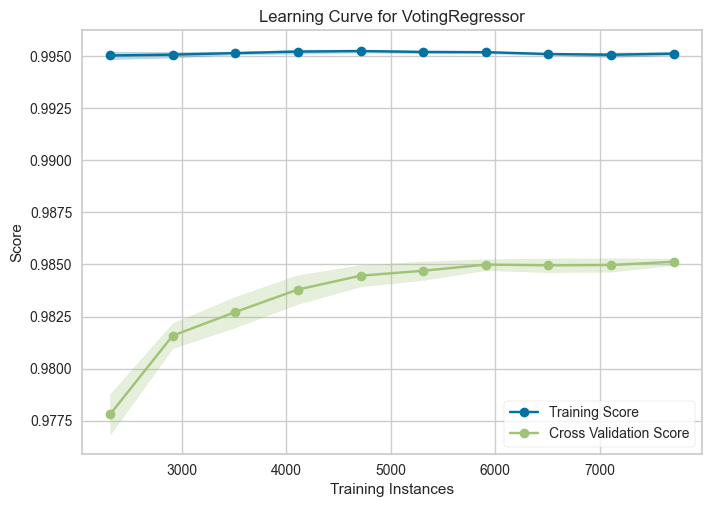

In [69]:
s.plot_model(blended, plot='learning')

#  결과 비교
## XGBoosting 성능

In [71]:
# 1. Hold-out 평가 실행
xgb_pred = s.predict_model(best5models[0])

# 2. 성능 지표 테이블 가져오기
xgb_metrics = s.pull()
xgb_metrics['Model'] = 'XGBoost'


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,3.0669,15.9328,3.9916,0.9856,0.0324,0.0255


## Voting 성능

In [72]:
vote_pred = s.predict_model(blended)

vote_metrics = s.pull()
vote_metrics['Model'] = 'Voting'


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Voting Regressor,3.2213,17.8322,4.2228,0.9839,0.0342,0.0269


## 비교 표

In [73]:
import pandas as pd

comparison_table = pd.concat([xgb_metrics, vote_metrics], axis=0)
comparison_table


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,XGBoost,3.0669,15.9328,3.9916,0.9856,0.0324,0.0255
0,Voting,3.2213,17.8322,4.2228,0.9839,0.0342,0.0269


-> XGBoost 선택

# 최종 모델 생성 (훈련데이터)


In [74]:
xgb_model = s.create_model('xgboost')

tuned_xgb = s.tune_model(xgb_model)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.0987,17.0752,4.1322,0.9851,0.0338,0.0261
1,3.1205,17.2093,4.1484,0.9852,0.0332,0.0259
2,3.1426,16.9437,4.1163,0.9858,0.0337,0.0265
3,3.1557,16.9706,4.1195,0.9862,0.0336,0.0266
4,3.0739,16.5360,4.0664,0.9862,0.0332,0.0260
Mean,3.1183,16.9470,4.1166,0.9857,0.0335,0.0262
Std,0.0295,0.2257,0.0275,0.0004,0.0002,0.0003


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.2735,18.2446,4.2714,0.9841,0.0357,0.0279
1,3.2653,18.2295,4.2696,0.9844,0.0350,0.0273
2,3.3743,18.6653,4.3203,0.9844,0.0361,0.0288
3,3.4415,19.8017,4.4499,0.9839,0.0367,0.0292
4,3.3275,18.2601,4.2732,0.9847,0.0356,0.0285
Mean,3.3364,18.6402,4.3169,0.9843,0.0358,0.0284
Std,0.0657,0.6032,0.0692,0.0003,0.0006,0.0007


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [75]:
s.pull()

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.2735,18.2446,4.2714,0.9841,0.0357,0.0279
1,3.2653,18.2295,4.2696,0.9844,0.0350,0.0273
2,3.3743,18.6653,4.3203,0.9844,0.0361,0.0288
3,3.4415,19.8017,4.4499,0.9839,0.0367,0.0292
4,3.3275,18.2601,4.2732,0.9847,0.0356,0.0285
Mean,3.3364,18.6402,4.3169,0.9843,0.0358,0.0284
Std,0.0657,0.6032,0.0692,0.0003,0.0006,0.0007


In [76]:
%%time
tuned_xgb = s.tune_model(
    estimator=xgb_model,
    optimize="RMSE",
    n_iter=30,
    fold=5,
    choose_better=True,
    verbose=False,
    early_stopping=True,

    search_algorithm="grid",
    custom_grid={
        "n_estimators": [200, 400, 600],
        "max_depth": [3,5,7,9],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.9, 1],
        "colsample_bytree": [0.7, 0.9, 1]
    }
)
tuned_xgb

CPU times: total: 24.3 s
Wall time: 3min 7s


XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
             device='cpu', early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=600,
             n_jobs=-1, num_parallel_tree=None, random_state=52, ...)

In [77]:
default_param = xgb_model.get_xgb_params()
tuned_param = tuned_xgb.get_xgb_params()

import pandas as pd

compare = pd.DataFrame({
    "Default": default_param,
    "Tuned": tuned_param
})

compare

,Default,Tuned
objective,reg:squarederror,reg:squarederror
base_score,None,None
booster,gbtree,gbtree
colsample_bylevel,None,None
colsample_bynode,None,None
colsample_bytree,None,1
device,cpu,cpu
eval_metric,None,None
gamma,None,None
grow_policy,None,None


In [78]:
s.pull()

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.9104,15.4086,3.9254,0.9866,0.0321,0.0245
1,2.8656,15.1752,3.8955,0.9870,0.0315,0.0239
2,3.0030,16.0143,4.0018,0.9866,0.0327,0.0253
3,3.0153,15.9052,3.9881,0.9871,0.0325,0.0254
4,2.9315,15.8501,3.9812,0.9867,0.0321,0.0247
Mean,2.9451,15.6707,3.9584,0.9868,0.0322,0.0248
Std,0.0565,0.3223,0.0408,0.0002,0.0004,0.0006


# 튜닝 전후 최종 모델 결과값

In [80]:
pred = s.predict_model(tuned_xgb)
pred.head()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,2.9305,15.3323,3.9157,0.9862,0.0315,0.0243


,CountyName,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,PrimaryCareShortageArea,MentalHealthShortageArea,population,LICENSED_BED_SIZE_ENCODED,yj_EDStations,yj_EDDXCount,yj_Tot_ED_NmbVsts,prediction_label
4093,Los Angeles,Investor Owned,Urban,Non-Teaching,Cancer,No,No,10014009,5,3.124918,4.936761,105.569427,101.217957
11031,San Francisco,Nonprofit,Urban,Non-Teaching,Sepsis,No,Yes,873965,5,4.737931,4.225372,117.528587,112.414513
6628,Los Angeles,Nonprofit,Urban,Non-Teaching,Homeless,No,No,10014009,6,4.257248,6.472135,119.131050,125.787758
6960,Sacramento,Government,Urban,Teaching,Hypertension,No,No,1585055,7,5.848973,8.945493,156.374802,152.744858
12444,Los Angeles,Nonprofit,Urban,Non-Teaching,Substance Abuse,No,No,10014009,6,4.485507,7.358870,146.289017,140.145325


In [82]:
pred_default = s.predict_model(xgb_model)
pred_tuned = s.predict_model(tuned_xgb)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,3.0669,15.9328,3.9916,0.9856,0.0324,0.0255


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,2.9305,15.3323,3.9157,0.9862,0.0315,0.0243


In [83]:
pred_tuned = s.predict_model(tuned_xgb)
s.pull()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,2.9305,15.3323,3.9157,0.9862,0.0315,0.0243


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,2.9305,15.3323,3.9157,0.9862,0.0315,0.0243


In [84]:
df49

,CountyName,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,population,LICENSED_BED_SIZE_ENCODED,yj_Tot_ED_NmbVsts,yj_EDStations,yj_EDDXCount
0,Alameda,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,No,No,1682353,3,86.749531,3.124918,6.037493
1,Alameda,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,No,No,1682353,6,116.593580,3.998156,6.793532
2,Alameda,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,No,No,1682353,4,123.990414,4.962100,7.195313
3,Alameda,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,No,No,1682353,5,157.170751,5.451428,7.329390
4,Alameda,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,No,No,1682353,6,115.967107,4.485507,6.902624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12844,Ventura,Nonprofit,Urban,Non-Teaching,Substance Abuse,29223,18.0,1922,No,No,843843,3,115.799180,3.697423,7.244312
12845,Ventura,Nonprofit,Urban,Non-Teaching,Substance Abuse,39699,31.0,2678,No,Yes,843843,5,129.897948,4.538632,7.547861
12846,Yolo,Nonprofit,Urban,Non-Teaching,Substance Abuse,22210,17.0,1244,No,Yes,216403,3,104.448408,3.613862,6.844541
12847,Yolo,Nonprofit,Urban,Non-Teaching,Substance Abuse,24455,11.0,1162,No,Yes,216403,1,108.301940,3.008249,6.781710


# 훈련데이터 예측 결과

In [85]:
train_pred = s.predict_model(tuned_xgb, data=s.get_config('X_train'))
s.pull()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,2.9305,15.3323,3.9157,0.9862,0.0315,0.0243


# 검증데이터 예측 결과

In [86]:
holdout_pred = s.predict_model(tuned_xgb)
s.pull()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,2.9305,15.3323,3.9157,0.9862,0.0315,0.0243


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,2.9305,15.3323,3.9157,0.9862,0.0315,0.0243


In [ ]:
s.evaluate_model(estimator=tuned_xgb)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

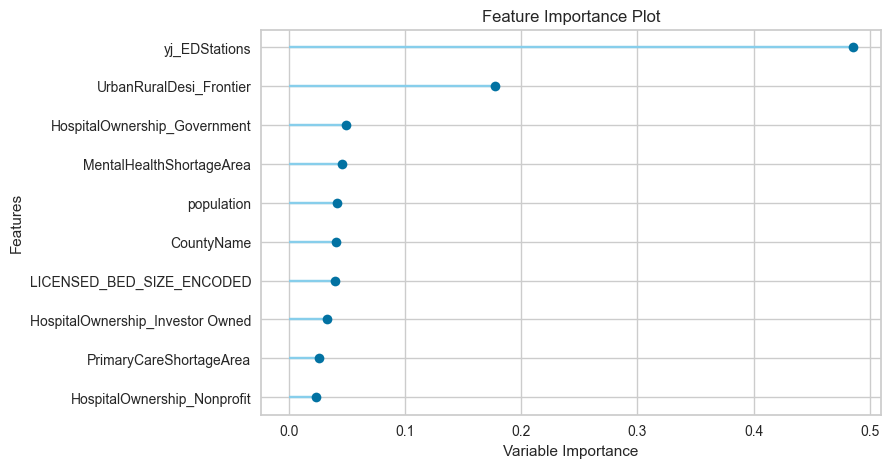

In [88]:
s.plot_model(tuned_xgb, plot='feature')

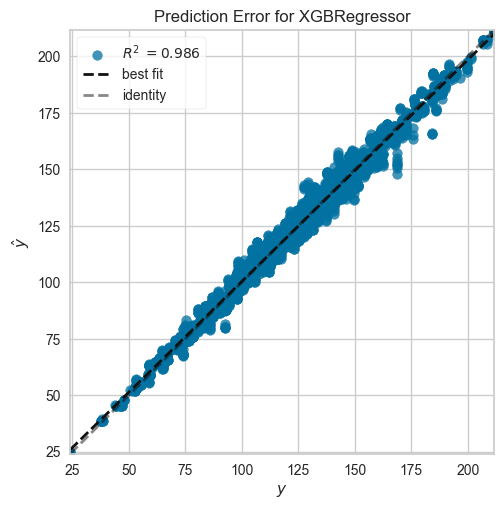

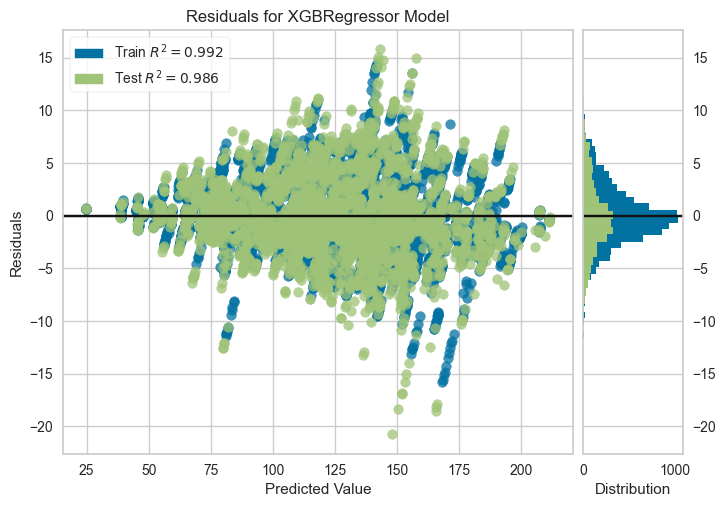

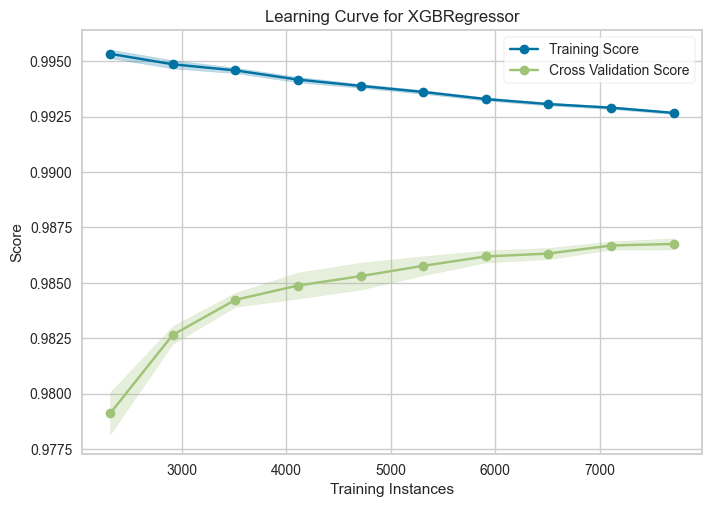

In [89]:
s.plot_model(tuned_xgb, plot='error')           # 예측 오차 확인
s.plot_model(tuned_xgb, plot='residuals')        # 잔차(과적합)  확인
s.plot_model(tuned_xgb, plot='learning')

In [91]:
# 실전 데이터 예측 성능 확인 (25% 홀드아웃 데이터)
holdout_pred = s.predict_model(tuned_xgb)
s.pull()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,2.9305,15.3323,3.9157,0.9862,0.0315,0.0243


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,2.9305,15.3323,3.9157,0.9862,0.0315,0.0243


In [92]:
s.interpret_model(tuned_xgb, plot='reason', observation=0)

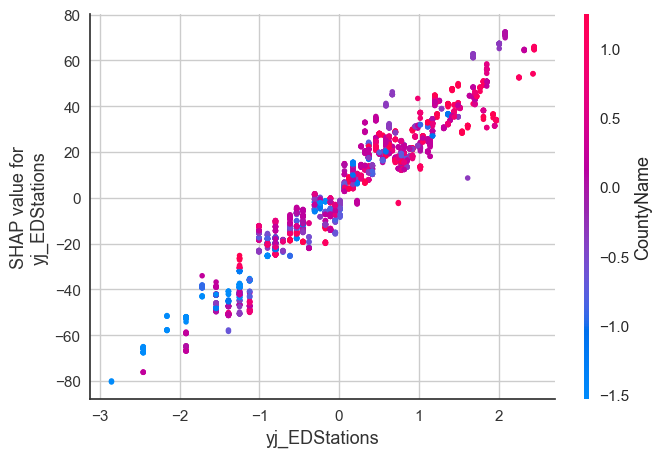

In [94]:
# 2. 특정 변수(log_EDStations)의 수치 변화에 따른 SHAP Value 변화량 시각화
s.interpret_model(tuned_xgb, plot='correlation', feature='yj_EDStations')

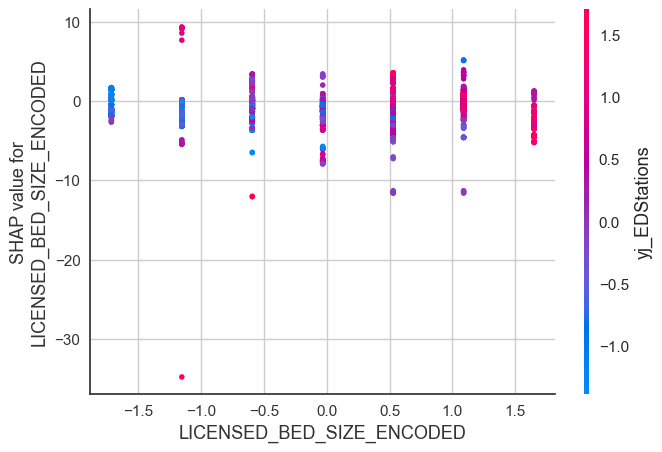

In [95]:
s.interpret_model(tuned_xgb, plot="correlation", feature="LICENSED_BED_SIZE_ENCODED")

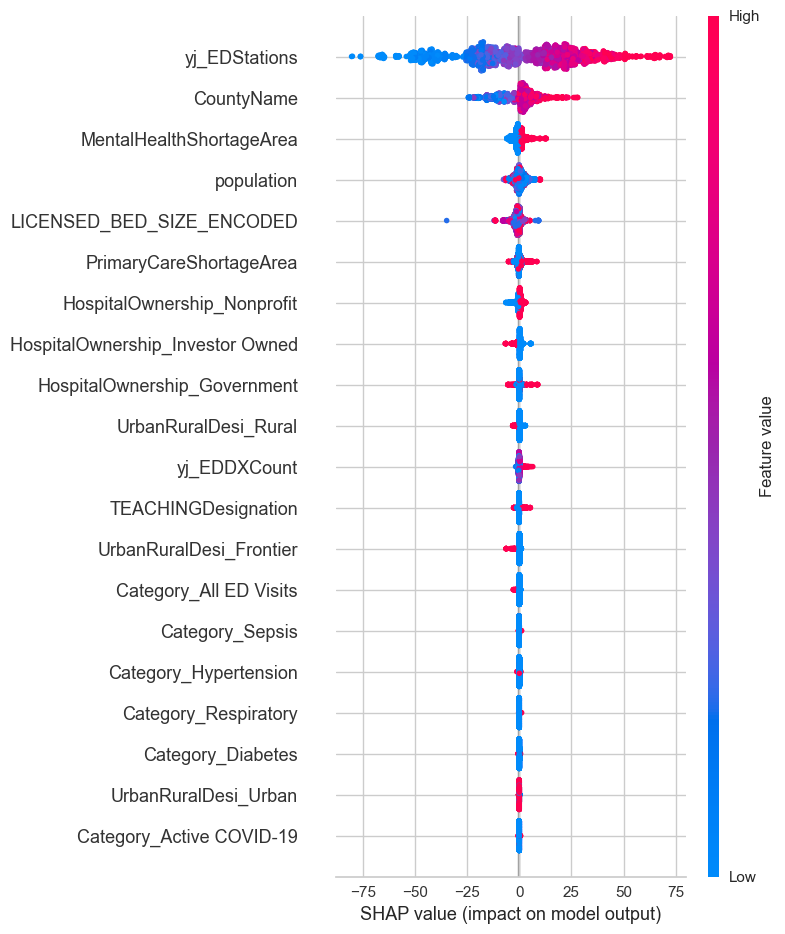

In [96]:
s.interpret_model(tuned_xgb)

In [97]:
final_model = s.finalize_model(tuned_xgb)
final_model

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['population',
                                             'LICENSED_BED_SIZE_ENCODED',
                                             'yj_EDStations', 'yj_EDDXCount'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=['CountyName', 'HospitalOwnership',
                                             'UrbanRuralDesi',
                                             'TEACHINGDesignation', 'Category',
                                             'PrimaryCareShortag...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.01,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=9, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=600, n_jobs=-1,
                              num_parallel_tree=None, random_state=52, ...))])

Train R^2: 0.994, Test R^2: 0.988 로 두 수치의 차이가 크지 않아 과적합 문제는 발생하지 않을 것으로 판단됨. 그래프 개형 또한 시행을 추가한다면 만날것으로 예측되는 개형.

In [98]:
s.save_model(final_model, 'Final_Model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['population',
                                              'LICENSED_BED_SIZE_ENCODED',
                                              'yj_EDStations', 'yj_EDDXCount'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=['CountyName', 'HospitalOwnership',
                                              'UrbanRuralDesi',
                                              'TEACHINGDesignation', 'Category',
                                              'PrimaryCareShortag...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                  

In [99]:
x = s.get_config("X")
y = s.get_config("y")

x_train = s.get_config("X_train")
y_train = s.get_config("y_train")

x_test = s.get_config("X_test")
y_test = s.get_config("y_test")

x_train_transformed = s.get_config("X_train_transformed")
y_train_transformed = s.get_config("y_train_transformed")

x_test_transformed = s.get_config("X_test_transformed")
y_test_transformed = s.get_config("y_test_transformed")

x_transformed = concat([x_train_transformed, x_test_transformed])
y_transformed = concat([y_train_transformed, y_test_transformed])

(x.shape, y.shape), (x_train.shape, y_train.shape), (x_test.shape, y_test.shape), (x_train_transformed.shape, y_train_transformed.shape), (x_test_transformed.shape, y_test_transformed.shape)

(((12849, 11), (12849,)),
 ((9636, 11), (9636,)),
 ((3213, 11), (3213,)),
 ((9636, 31), (9636,)),
 ((3213, 31), (3213,)))

In [100]:
x_train

,CountyName,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,PrimaryCareShortageArea,MentalHealthShortageArea,population,LICENSED_BED_SIZE_ENCODED,yj_EDStations,yj_EDDXCount
1812,Kern,Nonprofit,Rural,Non-Teaching,Asthma,Yes,Yes,909235,2,3.124918,5.350964
2370,Los Angeles,Nonprofit,Urban,Non-Teaching,COPD,No,No,10014009,5,4.784797,6.194798
495,Stanislaus,Government,Rural,Non-Teaching,Active COVID-19,Yes,No,552878,1,3.124918,5.112515
2313,Lake,Nonprofit,Rural,Non-Teaching,COPD,Yes,Yes,68163,1,3.124918,4.651031
3374,Los Angeles,Investor Owned,Urban,Non-Teaching,COVID-19 History,No,No,10014009,4,3.337004,4.090993
...,...,...,...,...,...,...,...,...,...,...,...
4247,Santa Barbara,Nonprofit,Urban,Teaching,Cancer,No,No,448229,6,4.962100,6.592919
7693,Orange,Nonprofit,Urban,Non-Teaching,Mental Health,No,No,3186989,6,4.784797,7.846545
11019,San Diego,Investor Owned,Urban,Non-Teaching,Sepsis,Yes,Yes,3298634,5,3.853891,2.992197
9884,Los Angeles,Investor Owned,Urban,Non-Teaching,Respiratory,Yes,Yes,10014009,3,2.600248,1.773550


In [101]:
x_train_transformed

,CountyName,HospitalOwnership_Nonprofit,HospitalOwnership_Government,HospitalOwnership_Investor Owned,UrbanRuralDesi_Rural,UrbanRuralDesi_Urban,UrbanRuralDesi_Frontier,TEACHINGDesignation,Category_Asthma,Category_COPD,...,Category_Cardiac,Category_Stroke,Category_All ED Visits,Category_Respiratory,PrimaryCareShortageArea,MentalHealthShortageArea,population,LICENSED_BED_SIZE_ENCODED,yj_EDStations,yj_EDDXCount
1812,-0.345413,0.835806,-0.447214,-0.569041,2.052873,-1.859851,-0.183229,-0.319592,3.969668,-0.250510,...,-0.246745,-0.250276,-0.250041,-0.249103,1.480468,1.210926,-0.612565,-1.151274,-0.797503,-0.293440
2370,0.196042,0.835806,-0.447214,-0.569041,-0.487122,0.537677,-0.183229,-0.319592,-0.251910,3.991863,...,-0.246745,-0.250276,-0.250041,-0.249103,-0.675462,-0.825814,1.816346,0.528992,0.628069,0.132062
495,1.056597,-1.196449,2.236068,-0.569041,2.052873,-1.859851,-0.183229,-0.319592,-0.251910,-0.250510,...,-0.246745,-0.250276,-0.250041,-0.249103,1.480468,-0.825814,-0.707631,-1.711363,-0.797503,-0.413677
2313,-1.236577,0.835806,-0.447214,-0.569041,2.052873,-1.859851,-0.183229,-0.319592,-0.251910,3.991863,...,-0.246745,-0.250276,-0.250041,-0.249103,1.480468,1.210926,-0.836940,-1.711363,-0.797503,-0.646378
3374,0.196042,-1.196449,-0.447214,1.757341,-0.487122,0.537677,-0.183229,-0.319592,-0.251910,-0.250510,...,-0.246745,-0.250276,-0.250041,-0.249103,-0.675462,-0.825814,1.816346,-0.031097,-0.615355,-0.928776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4247,-0.733471,0.835806,-0.447214,-0.569041,-0.487122,0.537677,-0.183229,3.128992,-0.251910,-0.250510,...,-0.246745,-0.250276,-0.250041,-0.249103,-0.675462,-0.825814,-0.735549,1.089081,0.780345,0.332813
7693,-0.334735,0.835806,-0.447214,-0.569041,-0.487122,0.537677,-0.183229,-0.319592,-0.251910,-0.250510,...,-0.246745,-0.250276,-0.250041,-0.249103,-0.675462,-0.825814,-0.004921,1.089081,0.628069,0.964950
11019,1.056847,-1.196449,-0.447214,1.757341,-0.487122,0.537677,-0.183229,-0.319592,-0.251910,-0.250510,...,-0.246745,-0.250276,-0.250041,-0.249103,1.480468,1.210926,0.024863,0.528992,-0.171431,-1.482841
9884,0.196042,-1.196449,-0.447214,1.757341,-0.487122,0.537677,-0.183229,-0.319592,-0.251910,-0.250510,...,-0.246745,-0.250276,-0.250041,4.014406,1.480468,1.210926,1.816346,-0.591185,-1.248111,-2.097340


In [102]:
pipeline = s.get_config('pipeline')
display(pipeline)

Pipeline(memory=FastMemory(location=C:\Users\itwill\AppData\Local\Temp\joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['population',
                                             'LICENSED_BED_SIZE_ENCODED',
                                             'yj_EDStations', 'yj_EDDXCount'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=['CountyName', 'HospitalOwnership',
                                             'UrbanRuralDesi',
                                             'TEACHINGDe...
                                             'UrbanRuralDesi', 'Category'],
                                    transformer=OneHotEncoder(cols=['HospitalOwnership',
                                                                    'UrbanRuralDesi',
                                                                    'Category'],
                                                              handle_missing='return_nan',
                                                              use_cat_names=True))),
                ('rest_encoding',
                 TransformerWrapper(include=['CountyName'],
                                    transformer=TargetEncoder(cols=['CountyName'],
                                                              handle_missing='return_nan'))),
                ('normalize',
                 TransformerWrapper(transformer=StandardScaler()))])

In [103]:
df47

,CountyName,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,population,LICENSED_BED_SIZE_ENCODED
0,Alameda,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,No,No,1682353,3
1,Alameda,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,No,No,1682353,6
2,Alameda,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,No,No,1682353,4
3,Alameda,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,No,No,1682353,5
4,Alameda,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,No,No,1682353,6
...,...,...,...,...,...,...,...,...,...,...,...,...
12844,Ventura,Nonprofit,Urban,Non-Teaching,Substance Abuse,29223,18.0,1922,No,No,843843,3
12845,Ventura,Nonprofit,Urban,Non-Teaching,Substance Abuse,39699,31.0,2678,No,Yes,843843,5
12846,Yolo,Nonprofit,Urban,Non-Teaching,Substance Abuse,22210,17.0,1244,No,Yes,216403,3
12847,Yolo,Nonprofit,Urban,Non-Teaching,Substance Abuse,24455,11.0,1162,No,Yes,216403,1


# SHAP 분석

In [104]:
import shap
import numpy as np
import matplotlib.pyplot as plt


In [105]:
booster = tuned_xgb.get_booster()

# 성능기여도(중요도)
imp = booster.get_score(importance_type="gain")
imp

{'CountyName': 1469.9747314453125,
 'HospitalOwnership_Nonprofit': 840.849609375,
 'HospitalOwnership_Government': 1779.1890869140625,
 'HospitalOwnership_Investor Owned': 1179.642822265625,
 'UrbanRuralDesi_Rural': 657.4154052734375,
 'UrbanRuralDesi_Urban': 57.675968170166016,
 'UrbanRuralDesi_Frontier': 6449.67578125,
 'TEACHINGDesignation': 401.329345703125,
 'Category_Asthma': 17.808870315551758,
 'Category_COPD': 14.634870529174805,
 'Category_Active COVID-19': 26.26248550415039,
 'Category_COVID-19 History': 24.163673400878906,
 'Category_Mental Health': 15.872665405273438,
 'Category_Obesity': 18.088607788085938,
 'Category_Substance Abuse': 17.489925384521484,
 'Category_Pneumonia': 17.163190841674805,
 'Category_Homeless': 14.250605583190918,
 'Category_Hypertension': 31.02591896057129,
 'Category_Sepsis': 17.215898513793945,
 'Category_Cancer': 15.736191749572754,
 'Category_Diabetes': 21.019376754760742,
 'Category_Cardiac': 18.46855926513672,
 'Category_Stroke': 12.4329681

In [106]:
from pandas import Series
imp_sr = Series(imp)
imp_sr

CountyName                           1469.974731
HospitalOwnership_Nonprofit           840.849609
HospitalOwnership_Government         1779.189087
HospitalOwnership_Investor Owned     1179.642822
UrbanRuralDesi_Rural                  657.415405
UrbanRuralDesi_Urban                   57.675968
UrbanRuralDesi_Frontier              6449.675781
TEACHINGDesignation                   401.329346
Category_Asthma                        17.808870
Category_COPD                          14.634871
Category_Active COVID-19               26.262486
Category_COVID-19 History              24.163673
Category_Mental Health                 15.872665
Category_Obesity                       18.088608
Category_Substance Abuse               17.489925
Category_Pneumonia                     17.163191
Category_Homeless                      14.250606
Category_Hypertension                  31.025919
Category_Sepsis                        17.215899
Category_Cancer                        15.736192
Category_Diabetes   

In [107]:
imp_df = DataFrame(imp_sr, columns=['importance'])
imp_df = imp_df.sort_values('importance', ascending=False)
imp_df

,importance
yj_EDStations,17684.775391
UrbanRuralDesi_Frontier,6449.675781
HospitalOwnership_Government,1779.189087
MentalHealthShortageArea,1656.766479
population,1499.246094
CountyName,1469.974731
LICENSED_BED_SIZE_ENCODED,1438.448975
HospitalOwnership_Investor Owned,1179.642822
PrimaryCareShortageArea,948.310303
HospitalOwnership_Nonprofit,840.849609


In [108]:
imp_df['ratio'] = imp_df['importance'] / imp_df['importance'].sum()
imp_df['cumsum'] = imp_df['ratio'].cumsum()
imp_df

,importance,ratio,cumsum
yj_EDStations,17684.775391,0.485412,0.485412
UrbanRuralDesi_Frontier,6449.675781,0.177031,0.662443
HospitalOwnership_Government,1779.189087,0.048835,0.711278
MentalHealthShortageArea,1656.766479,0.045475,0.756753
population,1499.246094,0.041151,0.797905
CountyName,1469.974731,0.040348,0.838253
LICENSED_BED_SIZE_ENCODED,1438.448975,0.039483,0.877735
HospitalOwnership_Investor Owned,1179.642822,0.032379,0.910114
PrimaryCareShortageArea,948.310303,0.026029,0.936143
HospitalOwnership_Nonprofit,840.849609,0.023080,0.959223


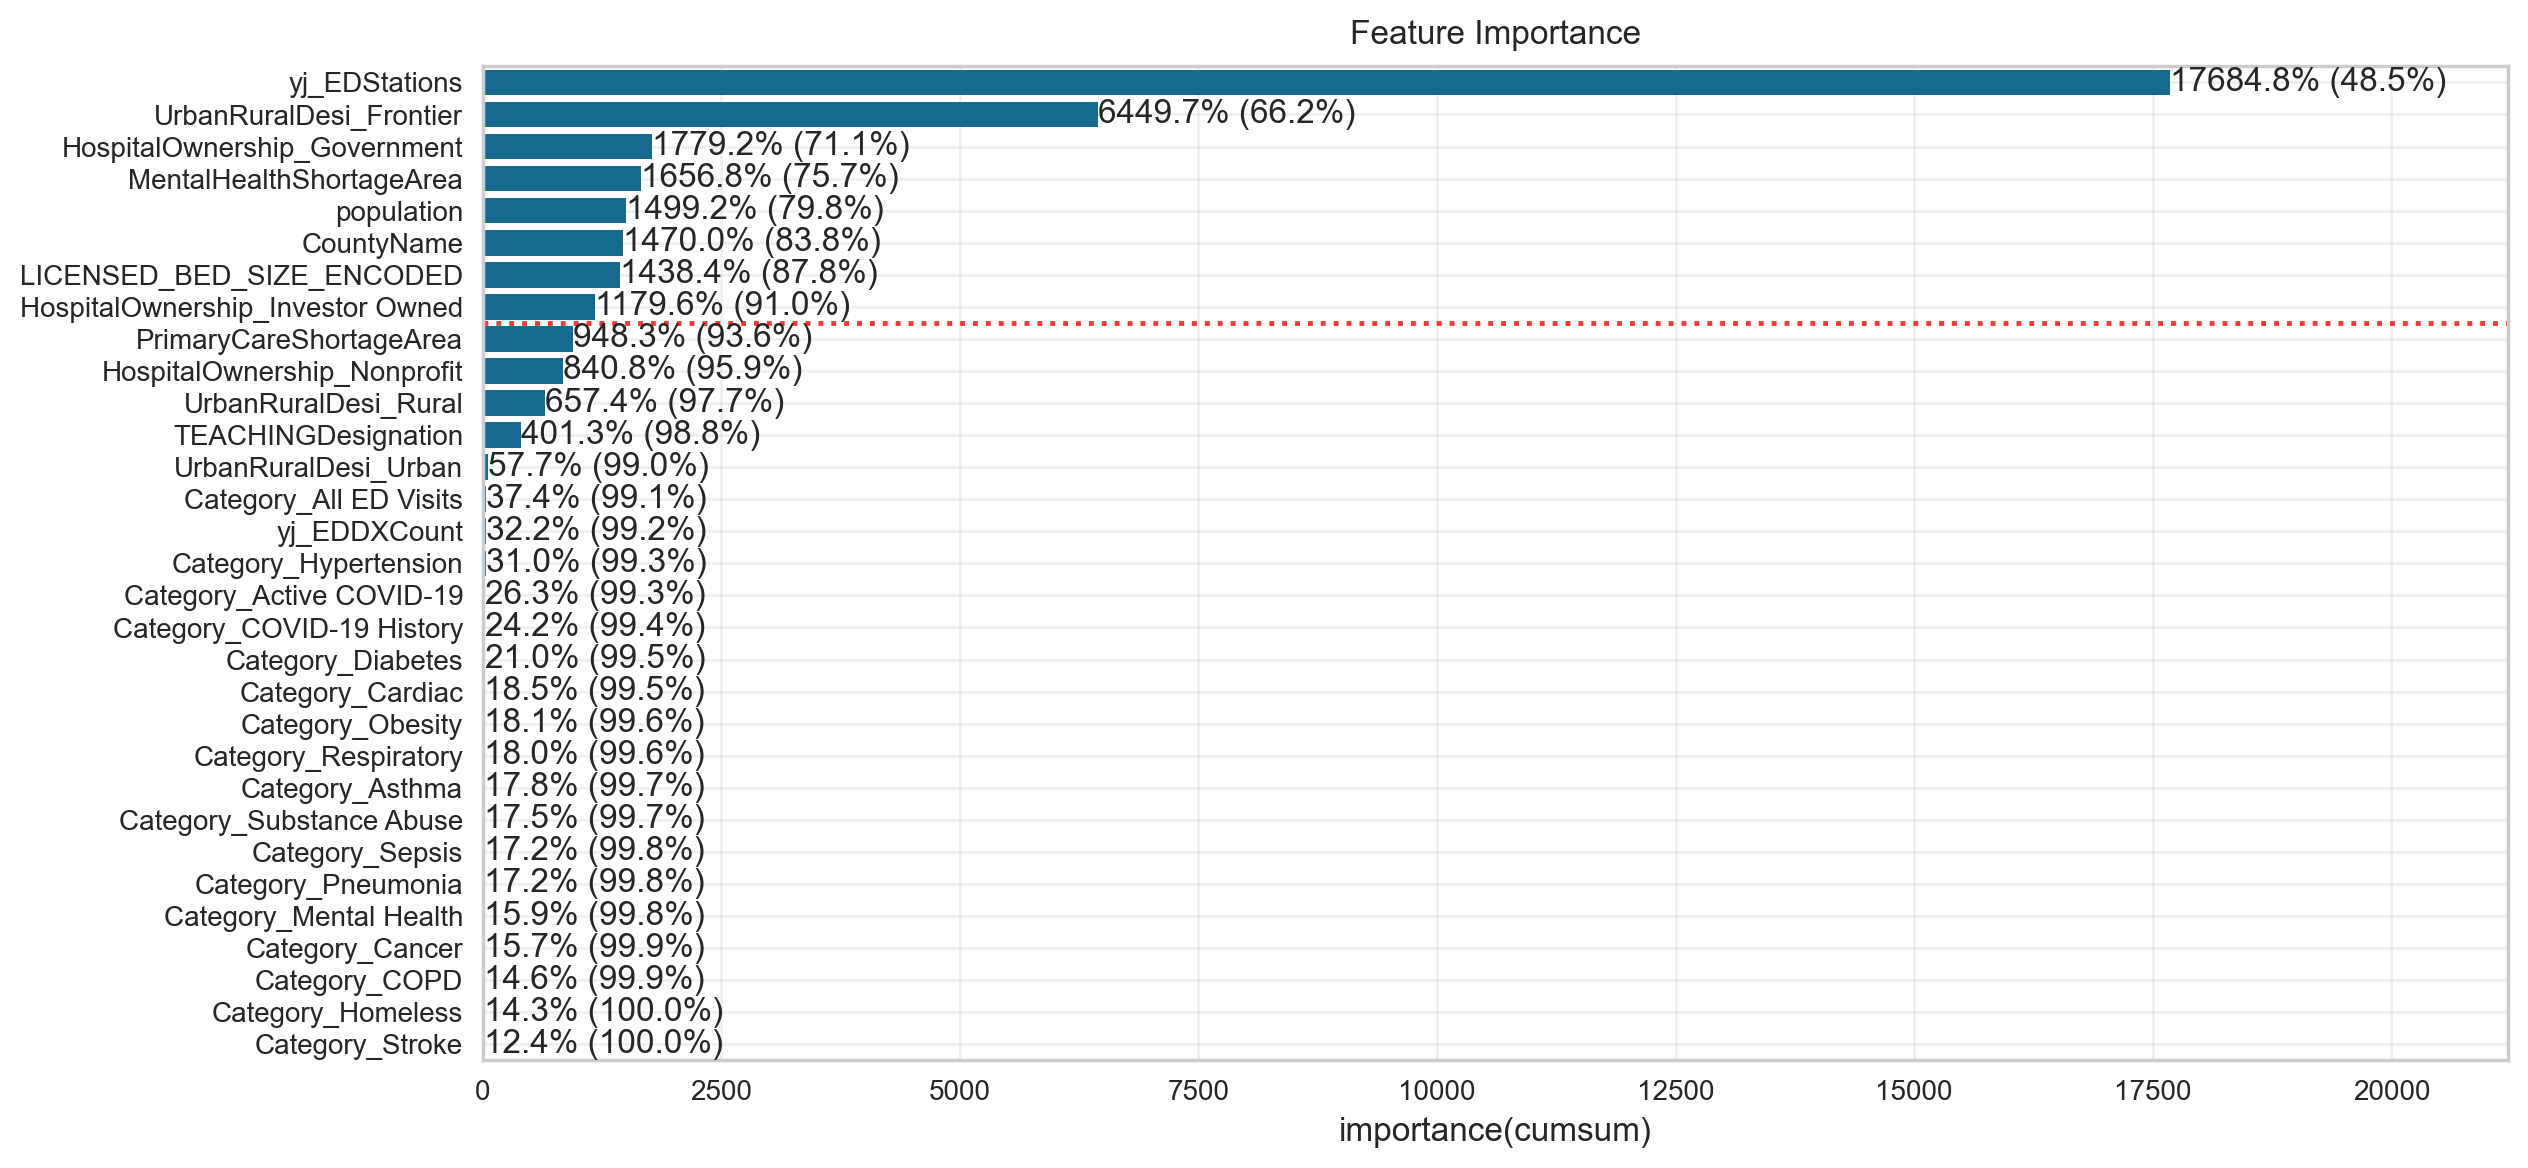

In [109]:
df = imp_df.sort_values(by="ratio", ascending=False)
threshold = 0.9

figsize = (1280 / 100, 600 / 100)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

sb.barplot(data=df, x='importance', y=df.index)

# 값 라벨 추가
for i, v in enumerate(imp_df["importance"]):
    ax.text(
        v + 0.005,
        i,
        f"{v:.1f}% ({imp_df.iloc[i]['cumsum']*100:.1f}%)",
        va="center")

ax.set_title("Feature Importance", fontsize=12, pad=8)
ax.set_xlabel("importance(cumsum)", fontsize=12)
ax.set_ylabel(None)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, imp_df["importance"].max()*1.2)

threshold = 0.9

# 90% 처음 도달하는 인덱스 (0-based)
cut_idx = np.argmax(imp_df["cumsum"].values >= threshold)

# X축은 rank 기준으로 +1
cut_rank = (int(cut_idx) + 1) - 0.5

# 90% 도달 지점 수직선 (핵심)
plt.axhline(
    y=cut_rank,
    linestyle=":",
    color="red",
    alpha=0.8
)

plt.tight_layout()
plt.show()
plt.close()

# 위경도 넣고 카운티 이름 뺀후 모델 돌려보기 (3/13)


In [110]:
df50 = df49.copy()
df50

,CountyName,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,population,LICENSED_BED_SIZE_ENCODED,yj_Tot_ED_NmbVsts,yj_EDStations,yj_EDDXCount
0,Alameda,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,No,No,1682353,3,86.749531,3.124918,6.037493
1,Alameda,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,No,No,1682353,6,116.593580,3.998156,6.793532
2,Alameda,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,No,No,1682353,4,123.990414,4.962100,7.195313
3,Alameda,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,No,No,1682353,5,157.170751,5.451428,7.329390
4,Alameda,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,No,No,1682353,6,115.967107,4.485507,6.902624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12844,Ventura,Nonprofit,Urban,Non-Teaching,Substance Abuse,29223,18.0,1922,No,No,843843,3,115.799180,3.697423,7.244312
12845,Ventura,Nonprofit,Urban,Non-Teaching,Substance Abuse,39699,31.0,2678,No,Yes,843843,5,129.897948,4.538632,7.547861
12846,Yolo,Nonprofit,Urban,Non-Teaching,Substance Abuse,22210,17.0,1244,No,Yes,216403,3,104.448408,3.613862,6.844541
12847,Yolo,Nonprofit,Urban,Non-Teaching,Substance Abuse,24455,11.0,1162,No,Yes,216403,1,108.301940,3.008249,6.781710


In [111]:
df4

,oshpd_id,FacilityName2,CountyName,system,year,LICENSED_BED_SIZE,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,LATITUDE,LONGITUDE,PrimaryCareShortageArea,MentalHealthShortageArea,Visits_Per_Station
0,106010735,Alameda Hospital,Alameda,Alameda Health System,2022,100-149,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,37.762660,-122.253991,No,No,43.333333
1,106010739,Alta Bates Summit Medical Center – Alta Bates ...,Alameda,Sutter Health,2022,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,37.856450,-122.257430,No,No,53.500000
2,106010776,UC San Francisco Benioff Children's Hospital O...,Alameda,NaN,2022,150-199,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,37.837220,-122.267470,No,No,45.550000
3,106010846,Highland Hospital,Alameda,Alameda Health System,2022,200-299,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,37.799250,-122.231380,No,No,39.792453
4,106010937,Alta Bates Summit Medical Center,Alameda,Sutter Health,2022,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,37.821060,-122.262570,No,No,44.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12844,106560525,Adventist Health Simi Valley,Ventura,Adventist Health Systems,2021,100-149,Nonprofit,Urban,Non-Teaching,Substance Abuse,29223,18.0,1922,34.289730,-118.743940,No,No,106.777778
12845,106560529,St. John's Regional Medical Center,Ventura,Dignity Health,2021,200-299,Nonprofit,Urban,Non-Teaching,Substance Abuse,39699,31.0,2678,34.216870,-119.158190,No,Yes,86.387097
12846,106571086,Woodland Memorial Hospital,Yolo,Dignity Health,2021,100-149,Nonprofit,Urban,Non-Teaching,Substance Abuse,22210,17.0,1244,38.662840,-121.793300,No,Yes,73.176471
12847,106574010,Sutter Davis Hospital,Yolo,Sutter Health,2021,1-49,Nonprofit,Urban,Non-Teaching,Substance Abuse,24455,11.0,1162,38.562890,-121.771640,No,Yes,105.636364


In [112]:
def categorize_ed(row):
    if row['LICENSED_BED_SIZE_ENCODED'] <= 2: size = 'Small'
    elif row['LICENSED_BED_SIZE_ENCODED'] <= 5: size = 'Medium'
    else: size = 'Large'

    is_frontier = 'Frontier' if row['UrbanRuralDesi'] == 'Frontier' else 'Non-Frontier'

    return f"{is_frontier}_{size}"

df50['ED_Group'] = df50.apply(categorize_ed, axis=1)

persona_analysis = df50.groupby('ED_Group').agg({
    'Tot_ED_NmbVsts': 'mean',
    'EDStations': 'mean',
}).sort_values(by='Tot_ED_NmbVsts', ascending=False)

In [113]:
persona_analysis

,Tot_ED_NmbVsts,EDStations
ED_Group,,
Non-Frontier_Large,60948.499591,47.423276
Non-Frontier_Medium,36987.262274,25.296801
Non-Frontier_Small,20436.210081,12.941129
Frontier_Medium,5266.333333,7.000000
Frontier_Small,3465.989437,2.904930


In [114]:
persona_analysis['total_all_visits'] = persona_analysis['Tot_ED_NmbVsts'].sum()
persona_analysis['visits_ratio'] = (persona_analysis['Tot_ED_NmbVsts'] / persona_analysis['total_all_visits'])*100
persona_analysis['visits_per_station'] = (persona_analysis['Tot_ED_NmbVsts'] / persona_analysis['EDStations'])
persona_analysis


,Tot_ED_NmbVsts,EDStations,total_all_visits,visits_ratio,visits_per_station
ED_Group,,,,,
Non-Frontier_Large,60948.499591,47.423276,127104.294716,47.951566,1285.202217
Non-Frontier_Medium,36987.262274,25.296801,127104.294716,29.099931,1462.132015
Non-Frontier_Small,20436.210081,12.941129,127104.294716,16.078300,1579.167477
Frontier_Medium,5266.333333,7.000000,127104.294716,4.143317,752.333333
Frontier_Small,3465.989437,2.904930,127104.294716,2.726886,1193.140606


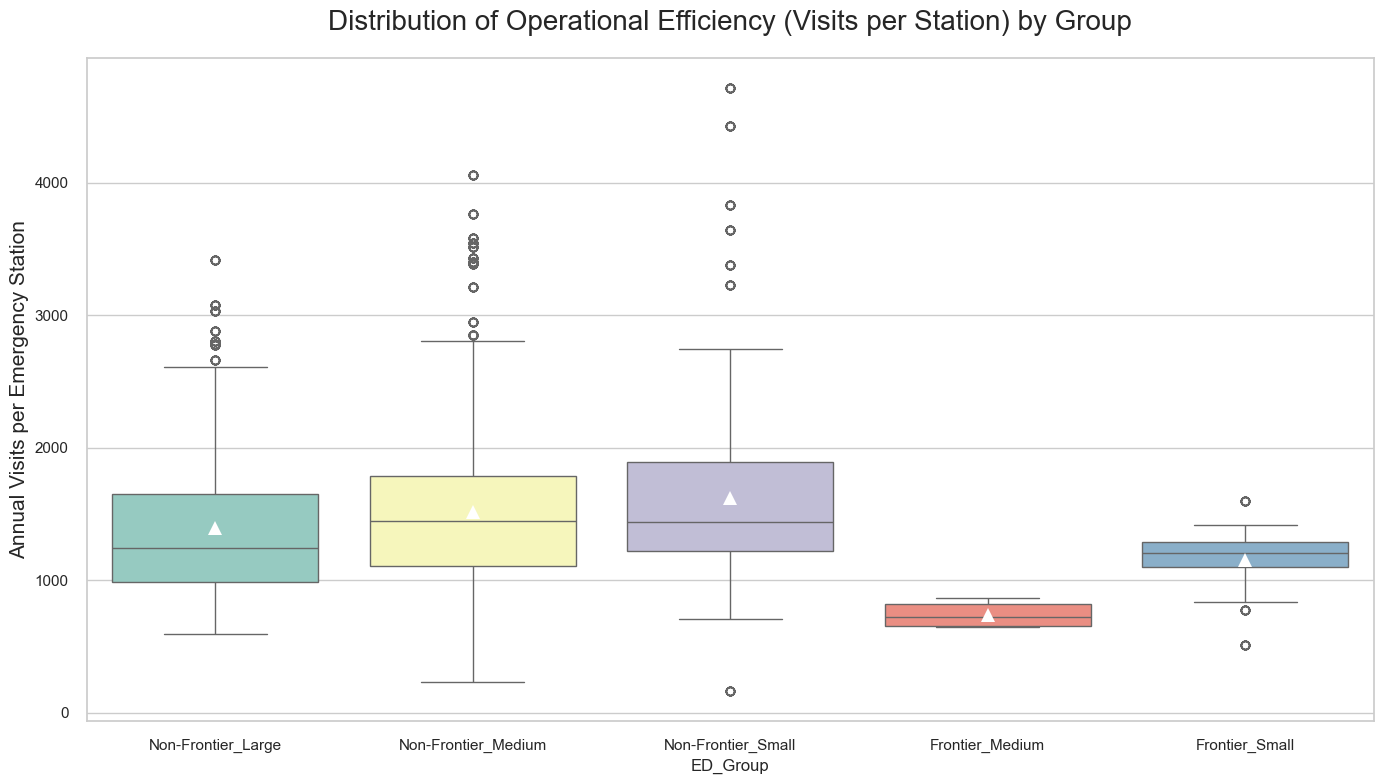

In [115]:
import seaborn as sb
import matplotlib.pyplot as plt

# 1. 시각화용 개별 병원 효율성 지표 생성 (원시 데이터 df50 활용)
# 분모(EDStations)가 0인 경우를 대비해 아주 작은 값을 더하거나 필터링합니다.
df50['visits_per_station'] = df50['Tot_ED_NmbVsts'] / df50['EDStations'].replace(0, 1)

# 2. 그래프 크기 및 스타일 설정
plt.figure(figsize=(14, 8))
sb.set_theme(style="whitegrid")

# 3. 페르소나 그룹 순서 정의
order_list = [
    'Non-Frontier_Large', 'Non-Frontier_Medium', 'Non-Frontier_Small', 
    'Frontier_Medium', 'Frontier_Small'
]

# 4. Boxplot 생성
ax = sb.boxplot(
    data=df50, 
    x='ED_Group', 
    y='visits_per_station', 
    order=order_list,
    palette='Set3',
    showmeans=True, # 평균값(세모) 표시
    meanprops={"marker":"^", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"10"}
)

# 5. 그래프 가독성 높이기
plt.title('Distribution of Operational Efficiency (Visits per Station) by Group', fontsize=20, pad=20)
plt.ylabel('Annual Visits per Emergency Station', fontsize=15)

# 이상치가 너무 커서 상자가 작게 보인다면 y축 범위를 제한하거나 로그 스케일을 씁니다.
# plt.ylim(0, 5000) # 필요시 활성화

plt.tight_layout()
plt.show()

In [116]:
df4['LICENSED_BED_SIZE'].value_counts()

LICENSED_BED_SIZE
300-499    3125
200-299    2411
100-149    2307
150-199    1698
1-49       1508
50-99      1256
500+        544
Name: count, dtype: int64

In [117]:
df48['LICENSED_BED_SIZE_ENCODED'].value_counts()

LICENSED_BED_SIZE_ENCODED
6    3125
5    2411
3    2307
4    1698
1    1508
2    1256
7     544
Name: count, dtype: int64

In [118]:
from pyproj import Transformer

df700 = df4.copy()

transformer = Transformer.from_crs("epsg:4326", "epsg:3857", always_xy=True)
df700['LONGITUDE_3857'], df700['LATITUDE_3857'] = transformer.transform(df700['LONGITUDE'].values, df700['LATITUDE'].values)
df700.to_excel('ED_DATA_METRIC.xlsx', index=False)

In [119]:
df700

,oshpd_id,FacilityName2,CountyName,system,year,LICENSED_BED_SIZE,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,LATITUDE,LONGITUDE,PrimaryCareShortageArea,MentalHealthShortageArea,Visits_Per_Station,LONGITUDE_3857,LATITUDE_3857
0,106010735,Alameda Hospital,Alameda,Alameda Health System,2022,100-149,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,37.762660,-122.253991,No,No,43.333333,-1.360925e+07,4.545952e+06
1,106010739,Alta Bates Summit Medical Center – Alta Bates ...,Alameda,Sutter Health,2022,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,37.856450,-122.257430,No,No,53.500000,-1.360963e+07,4.559167e+06
2,106010776,UC San Francisco Benioff Children's Hospital O...,Alameda,NaN,2022,150-199,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,37.837220,-122.267470,No,No,45.550000,-1.361075e+07,4.556456e+06
3,106010846,Highland Hospital,Alameda,Alameda Health System,2022,200-299,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,37.799250,-122.231380,No,No,39.792453,-1.360673e+07,4.551105e+06
4,106010937,Alta Bates Summit Medical Center,Alameda,Sutter Health,2022,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,37.821060,-122.262570,No,No,44.166667,-1.361021e+07,4.554178e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12844,106560525,Adventist Health Simi Valley,Ventura,Adventist Health Systems,2021,100-149,Nonprofit,Urban,Non-Teaching,Substance Abuse,29223,18.0,1922,34.289730,-118.743940,No,No,106.777778,-1.321851e+07,4.067772e+06
12845,106560529,St. John's Regional Medical Center,Ventura,Dignity Health,2021,200-299,Nonprofit,Urban,Non-Teaching,Substance Abuse,39699,31.0,2678,34.216870,-119.158190,No,Yes,86.387097,-1.326463e+07,4.057960e+06
12846,106571086,Woodland Memorial Hospital,Yolo,Dignity Health,2021,100-149,Nonprofit,Urban,Non-Teaching,Substance Abuse,22210,17.0,1244,38.662840,-121.793300,No,Yes,73.176471,-1.355797e+07,4.673491e+06
12847,106574010,Sutter Davis Hospital,Yolo,Sutter Health,2021,1-49,Nonprofit,Urban,Non-Teaching,Substance Abuse,24455,11.0,1162,38.562890,-121.771640,No,Yes,105.636364,-1.355556e+07,4.659251e+06


In [120]:
df4

,oshpd_id,FacilityName2,CountyName,system,year,LICENSED_BED_SIZE,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,LATITUDE,LONGITUDE,PrimaryCareShortageArea,MentalHealthShortageArea,Visits_Per_Station
0,106010735,Alameda Hospital,Alameda,Alameda Health System,2022,100-149,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,37.762660,-122.253991,No,No,43.333333
1,106010739,Alta Bates Summit Medical Center – Alta Bates ...,Alameda,Sutter Health,2022,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,37.856450,-122.257430,No,No,53.500000
2,106010776,UC San Francisco Benioff Children's Hospital O...,Alameda,NaN,2022,150-199,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,37.837220,-122.267470,No,No,45.550000
3,106010846,Highland Hospital,Alameda,Alameda Health System,2022,200-299,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,37.799250,-122.231380,No,No,39.792453
4,106010937,Alta Bates Summit Medical Center,Alameda,Sutter Health,2022,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,37.821060,-122.262570,No,No,44.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12844,106560525,Adventist Health Simi Valley,Ventura,Adventist Health Systems,2021,100-149,Nonprofit,Urban,Non-Teaching,Substance Abuse,29223,18.0,1922,34.289730,-118.743940,No,No,106.777778
12845,106560529,St. John's Regional Medical Center,Ventura,Dignity Health,2021,200-299,Nonprofit,Urban,Non-Teaching,Substance Abuse,39699,31.0,2678,34.216870,-119.158190,No,Yes,86.387097
12846,106571086,Woodland Memorial Hospital,Yolo,Dignity Health,2021,100-149,Nonprofit,Urban,Non-Teaching,Substance Abuse,22210,17.0,1244,38.662840,-121.793300,No,Yes,73.176471
12847,106574010,Sutter Davis Hospital,Yolo,Sutter Health,2021,1-49,Nonprofit,Urban,Non-Teaching,Substance Abuse,24455,11.0,1162,38.562890,-121.771640,No,Yes,105.636364


In [121]:
df50

,CountyName,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,population,LICENSED_BED_SIZE_ENCODED,yj_Tot_ED_NmbVsts,yj_EDStations,yj_EDDXCount,ED_Group,visits_per_station
0,Alameda,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,No,No,1682353,3,86.749531,3.124918,6.037493,Non-Frontier_Medium,1131.583333
1,Alameda,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,No,No,1682353,6,116.593580,3.998156,6.793532,Non-Frontier_Large,1352.727273
2,Alameda,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,No,No,1682353,4,123.990414,4.962100,7.195313,Non-Frontier_Medium,876.550000
3,Alameda,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,No,No,1682353,5,157.170751,5.451428,7.329390,Non-Frontier_Medium,1247.075472
4,Alameda,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,No,No,1682353,6,115.967107,4.485507,6.902624,Non-Frontier_Large,977.866667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12844,Ventura,Nonprofit,Urban,Non-Teaching,Substance Abuse,29223,18.0,1922,No,No,843843,3,115.799180,3.697423,7.244312,Non-Frontier_Medium,1623.500000
12845,Ventura,Nonprofit,Urban,Non-Teaching,Substance Abuse,39699,31.0,2678,No,Yes,843843,5,129.897948,4.538632,7.547861,Non-Frontier_Medium,1280.612903
12846,Yolo,Nonprofit,Urban,Non-Teaching,Substance Abuse,22210,17.0,1244,No,Yes,216403,3,104.448408,3.613862,6.844541,Non-Frontier_Medium,1306.470588
12847,Yolo,Nonprofit,Urban,Non-Teaching,Substance Abuse,24455,11.0,1162,No,Yes,216403,1,108.301940,3.008249,6.781710,Non-Frontier_Small,2223.181818


In [122]:
df50 = df50.merge(df4[['Tot_ED_NmbVsts', 'FacilityName2']], on='Tot_ED_NmbVsts', how='left')
df50

,CountyName,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,population,LICENSED_BED_SIZE_ENCODED,yj_Tot_ED_NmbVsts,yj_EDStations,yj_EDDXCount,ED_Group,visits_per_station,FacilityName2
0,Alameda,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,No,No,1682353,3,86.749531,3.124918,6.037493,Non-Frontier_Medium,1131.583333,Alameda Hospital
1,Alameda,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,No,No,1682353,3,86.749531,3.124918,6.037493,Non-Frontier_Medium,1131.583333,Alameda Hospital
2,Alameda,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,No,No,1682353,3,86.749531,3.124918,6.037493,Non-Frontier_Medium,1131.583333,Alameda Hospital
3,Alameda,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,No,No,1682353,3,86.749531,3.124918,6.037493,Non-Frontier_Medium,1131.583333,Alameda Hospital
4,Alameda,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,No,No,1682353,3,86.749531,3.124918,6.037493,Non-Frontier_Medium,1131.583333,Alameda Hospital
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219850,Yuba,Nonprofit,Rural,Non-Teaching,Substance Abuse,55341,44.0,3942,Yes,Yes,81575,5,147.086171,5.125250,7.900262,Non-Frontier_Medium,1257.750000,Adventist Health and Rideout
219851,Yuba,Nonprofit,Rural,Non-Teaching,Substance Abuse,55341,44.0,3942,Yes,Yes,81575,5,147.086171,5.125250,7.900262,Non-Frontier_Medium,1257.750000,Adventist Health and Rideout
219852,Yuba,Nonprofit,Rural,Non-Teaching,Substance Abuse,55341,44.0,3942,Yes,Yes,81575,5,147.086171,5.125250,7.900262,Non-Frontier_Medium,1257.750000,Adventist Health and Rideout
219853,Yuba,Nonprofit,Rural,Non-Teaching,Substance Abuse,55341,44.0,3942,Yes,Yes,81575,5,147.086171,5.125250,7.900262,Non-Frontier_Medium,1257.750000,Adventist Health and Rideout


In [123]:
df_filtered = df50[df50['Category'] == 'All ED Visits']

df50_drop = df_filtered.drop_duplicates(subset=['FacilityName2'], keep='first')

print(len(df50))
print(len(df50_drop))

219855
315


In [124]:
df50_drop

,CountyName,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,population,LICENSED_BED_SIZE_ENCODED,yj_Tot_ED_NmbVsts,yj_EDStations,yj_EDDXCount,ED_Group,visits_per_station,FacilityName2
12951,Alameda,Government,Urban,Non-Teaching,All ED Visits,13579,12.0,13579,No,No,1682353,3,86.749531,3.124918,9.017424,Non-Frontier_Medium,1131.583333,Alameda Hospital
12968,Alameda,Nonprofit,Urban,Non-Teaching,All ED Visits,29760,22.0,29760,No,No,1682353,6,116.593580,3.998156,9.718073,Non-Frontier_Large,1352.727273,Alta Bates Summit Medical Center – Alta Bates ...
12985,Alameda,Nonprofit,Urban,Teaching,All ED Visits,35062,40.0,35062,No,No,1682353,4,123.990414,4.962100,9.863687,Non-Frontier_Medium,876.550000,UC San Francisco Benioff Children's Hospital O...
13002,Alameda,Government,Urban,Non-Teaching,All ED Visits,66095,53.0,66095,No,No,1682353,5,157.170751,5.451428,10.424196,Non-Frontier_Medium,1247.075472,Highland Hospital
13019,Alameda,Nonprofit,Urban,Non-Teaching,All ED Visits,29336,30.0,29336,No,No,1682353,6,115.967107,4.485507,9.705315,Non-Frontier_Large,977.866667,Alta Bates Summit Medical Center
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23591,Modoc,Government,Frontier,Non-Teaching,All ED Visits,4834,4.0,4834,Yes,Yes,8700,2,58.532385,1.819148,8.085583,Frontier_Small,1208.500000,Modoc Medical Center
23913,Orange,Nonprofit,Urban,Non-Teaching,All ED Visits,58831,56.0,58831,No,No,3186989,6,150.485197,5.549874,10.321567,Non-Frontier_Large,1050.553571,Providence St. Joseph Hospital
24270,Riverside,Government,Urban,Teaching,All ED Visits,68827,44.0,68827,No,Yes,2418185,6,159.564365,5.125250,10.459868,Non-Frontier_Large,1564.250000,Riverside University Health System – Medical C...
24899,San Francisco,Government,Urban,Teaching,All ED Visits,33076,52.0,33076,No,No,873965,7,121.308597,5.417577,9.811930,Non-Frontier_Large,636.076923,UC San Francisco Medical Center


In [125]:
df50_drop['ED_Group'].unique()

array(['Non-Frontier_Medium', 'Non-Frontier_Large', 'Non-Frontier_Small',
       'Frontier_Small', 'Frontier_Medium'], dtype=object)

# Non Frontier - Small, Medium 병원 top10개 조회

In [126]:
target_clusters = ['Non-Frontier_Medium', 'Non-Frontier_Small']

result1 = df50_drop[df50_drop['ED_Group'].isin(target_clusters)]

result1_top10 = result1.sort_values(by='Tot_ED_NmbVsts', ascending=False)

print(result1_top10[['FacilityName2', 'ED_Group', 'Tot_ED_NmbVsts']].head(10))

                                           FacilityName2             ED_Group  \
15323  Kaiser Foundation Hospital – Orange County – A...  Non-Frontier_Medium   
15714      Kaiser Foundation Hospital – South Sacramento  Non-Frontier_Medium   
16393               Kaiser Foundation Hospital – Manteca   Non-Frontier_Small   
15663            Kaiser Foundation Hospital – Sacramento  Non-Frontier_Medium   
14595         Martin Luther King, Jr. Community Hospital  Non-Frontier_Medium   
19835       Southwest Healthcare Rancho Springs Hospital  Non-Frontier_Medium   
15612             Southwest Healthcare System – Murrieta  Non-Frontier_Medium   
13628                           Adventist Health Hanford  Non-Frontier_Medium   
14069               Kaiser Foundation Hospital – West LA  Non-Frontier_Medium   
16190                             Palomar Medical Center  Non-Frontier_Medium   

       Tot_ED_NmbVsts  
15323          112366  
15714          109964  
16393          107498  
15663       

In [127]:
result1_top10.head(10)

,CountyName,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,population,LICENSED_BED_SIZE_ENCODED,yj_Tot_ED_NmbVsts,yj_EDStations,yj_EDDXCount,ED_Group,visits_per_station,FacilityName2
15323,Orange,Nonprofit,Urban,Non-Teaching,All ED Visits,112366,72.0,112366,No,No,3186989,5,191.536094,6.010628,10.890264,Non-Frontier_Medium,1560.638889,Kaiser Foundation Hospital – Orange County – A...
15714,Sacramento,Nonprofit,Urban,Non-Teaching,All ED Visits,109964,53.0,109964,No,No,1585055,5,190.002222,5.451428,10.871341,Non-Frontier_Medium,2074.792453,Kaiser Foundation Hospital – South Sacramento
16393,San Joaquin,Nonprofit,Urban,Non-Teaching,All ED Visits,107498,47.0,107498,No,Yes,779233,2,188.405250,5.239698,10.851474,Non-Frontier_Small,2287.191489,Kaiser Foundation Hospital – Manteca
15663,Sacramento,Nonprofit,Urban,Non-Teaching,All ED Visits,100947,59.0,100947,No,No,1585055,5,184.046915,5.644006,10.796371,Non-Frontier_Medium,1710.966102,Kaiser Foundation Hospital – Sacramento
14595,Los Angeles,Nonprofit,Urban,Teaching,All ED Visits,99493,29.0,99493,Yes,Yes,10014009,3,183.055455,4.430903,10.783651,Non-Frontier_Medium,3430.793103,"Martin Luther King, Jr. Community Hospital"
19835,Riverside,Investor Owned,Urban,Non-Teaching,All ED Visits,95797,53.0,95797,No,Yes,2418185,3,180.493198,5.451428,10.750451,Non-Frontier_Medium,1807.490566,Southwest Healthcare Rancho Springs Hospital
15612,Riverside,Investor Owned,Urban,Non-Teaching,All ED Visits,94786,53.0,94786,No,Yes,2418185,3,179.781451,5.451428,10.741144,Non-Frontier_Medium,1788.415094,Southwest Healthcare System – Murrieta
13628,Kings,Nonprofit,Urban,Non-Teaching,All ED Visits,92128,44.0,92128,Yes,Yes,152486,4,177.886981,5.125250,10.716186,Non-Frontier_Medium,2093.818182,Adventist Health Hanford
14069,Los Angeles,Nonprofit,Urban,Non-Teaching,All ED Visits,80860,53.0,80860,No,No,10014009,5,169.446406,5.451428,10.601610,Non-Frontier_Medium,1525.660377,Kaiser Foundation Hospital – West LA
16190,San Diego,Government,Urban,Non-Teaching,All ED Visits,77978,72.0,77978,No,Yes,3298634,5,167.169262,6.010628,10.569706,Non-Frontier_Medium,1083.027778,Palomar Medical Center


In [128]:
target_clusters1 = ['Frontier_Medium', 'Frontier_Small']

result2 = df50_drop[df50_drop['ED_Group'].isin(target_clusters1)]

result2_top10 = result2.sort_values(by='Tot_ED_NmbVsts', ascending=True)

print(result2_top10[['FacilityName2', 'ED_Group', 'Tot_ED_NmbVsts']].head(10))

                                  FacilityName2         ED_Group  \
14867        Surprise Valley Community Hospital   Frontier_Small   
13527                    Southern Inyo Hospital   Frontier_Small   
18158            Catalina Island Medical Center   Frontier_Small   
15425                  Seneca District Hospital   Frontier_Small   
22215          Jerold Phelps Community Hospital   Frontier_Small   
15408  Eastern Plumas Hospital – Portola Campus   Frontier_Small   
16816                  Mayers Memorial Hospital  Frontier_Medium   
23591                      Modoc Medical Center   Frontier_Small   
20209             Colorado River Medical Center   Frontier_Small   
13442                      Glenn Medical Center   Frontier_Small   

       Tot_ED_NmbVsts  
14867             511  
13527            1668  
18158            2364  
15425            2710  
22215            2837  
15408            3461  
16816            4154  
23591            4834  
20209            4913  
13442      

In [129]:
result2_top10

,CountyName,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,population,LICENSED_BED_SIZE_ENCODED,yj_Tot_ED_NmbVsts,yj_EDStations,yj_EDDXCount,ED_Group,visits_per_station,FacilityName2
14867,Modoc,Government,Frontier,Non-Teaching,All ED Visits,511,1.0,511,Yes,Yes,8700,1,24.154022,0.730263,6.021268,Frontier_Small,511.000000,Surprise Valley Community Hospital
13527,Inyo,Government,Frontier,Non-Teaching,All ED Visits,1668,2.0,1668,Yes,No,19016,1,38.740515,1.193793,7.114267,Frontier_Small,834.000000,Southern Inyo Hospital
18158,Los Angeles,Nonprofit,Frontier,Non-Teaching,All ED Visits,2364,2.0,2364,Yes,Yes,10014009,1,44.396799,1.193793,7.433862,Frontier_Small,1182.000000,Catalina Island Medical Center
15425,Plumas,Government,Frontier,Non-Teaching,All ED Visits,2710,2.0,2710,Yes,Yes,19790,1,46.817349,1.193793,7.558711,Frontier_Small,1355.000000,Seneca District Hospital
22215,Humboldt,Government,Frontier,Non-Teaching,All ED Visits,2837,2.0,2837,Yes,Yes,136463,1,47.656489,1.193793,7.600529,Frontier_Small,1418.500000,Jerold Phelps Community Hospital
15408,Plumas,Government,Frontier,Non-Teaching,All ED Visits,3461,3.0,3461,Yes,Yes,19790,1,51.467244,1.540103,7.781818,Frontier_Small,1153.666667,Eastern Plumas Hospital – Portola Campus
16816,Shasta,Government,Frontier,Non-Teaching,All ED Visits,4154,6.0,4154,Yes,Yes,182155,3,55.219099,2.257880,7.947893,Frontier_Medium,692.333333,Mayers Memorial Hospital
23591,Modoc,Government,Frontier,Non-Teaching,All ED Visits,4834,4.0,4834,Yes,Yes,8700,2,58.532385,1.819148,8.085583,Frontier_Small,1208.500000,Modoc Medical Center
20209,San Bernardino,Nonprofit,Frontier,Non-Teaching,All ED Visits,4913,4.0,4913,Yes,Yes,2181654,1,58.897699,1.819148,8.100293,Frontier_Small,1228.250000,Colorado River Medical Center
13442,Glenn,Investor Owned,Frontier,Non-Teaching,All ED Visits,6404,4.0,6404,Yes,Yes,28917,1,65.189307,1.819148,8.340404,Frontier_Small,1601.000000,Glenn Medical Center
